In [2]:
# ============================================================
# CÉLULA 1 — CARREGAMENTO DOS DADOS DA UNIDADE SELECIONADA
# ============================================================
#
# FASE 2 — TRATAMENTO DOS DADOS
#
# OBJETIVO
# ------------------------------------------------------------
# Carregar automaticamente:
#
#   1. a unidade escolhida pelo Notebook 1;
#   2. os dados horários correspondentes.
#
# A identidade da unidade NÃO é definida neste notebook.
#
# Isso garante independência entre:
#
#   FASE 1 — seleção da unidade
#   FASE 2 — tratamento dos dados
#
# Se outra unidade for selecionada no Notebook 1 e os arquivos
# do pipeline forem atualizados, este notebook passará a
# trabalhar automaticamente com a nova unidade.
# ============================================================


# ============================================================
# 1. IMPORTAÇÕES
# ============================================================

from google.colab import drive
from pathlib import Path

import json
import pandas as pd
import numpy as np


# ============================================================
# 2. MONTAR O GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive"
)


# ============================================================
# 3. PASTA RAIZ DO PROJETO
# ============================================================

ROOT = Path(
    "/content/drive/MyDrive/co2-cems-thermal-modeling"
)


# ============================================================
# 4. DIRETÓRIOS
# ============================================================

DATA = ROOT / "data"

DATA_RAW = DATA / "raw"

DATA_INTERIM = DATA / "interim"

DATA_PROCESSED = DATA / "processed"


OUTPUT = ROOT / "outputs"

REPORTS = OUTPUT / "reports"

FIGURES = OUTPUT / "figures"

TABLES = OUTPUT / "tables"


PIPELINE_DIR = (
    ROOT
    /
    "pipeline"
)


# ============================================================
# 5. ARQUIVOS PRODUZIDOS PELO NOTEBOOK 1
# ============================================================

CONFIG_PATH = (
    PIPELINE_DIR
    /
    "selected_unit.json"
)

RAW_DATA_PATH = (
    PIPELINE_DIR
    /
    "selected_unit_hourly_raw.parquet"
)


# ============================================================
# 6. VERIFICAR A EXISTÊNCIA DOS ARQUIVOS
# ============================================================

if not CONFIG_PATH.exists():

    raise FileNotFoundError(
        "\nArquivo selected_unit.json não encontrado.\n"
        "Execute primeiro o Notebook 1 — Seleção da Unidade."
    )


if not RAW_DATA_PATH.exists():

    raise FileNotFoundError(
        "\nArquivo selected_unit_hourly_raw.parquet "
        "não encontrado.\n"
        "Execute primeiro a exportação do Notebook 1."
    )


# ============================================================
# 7. CARREGAR IDENTIFICAÇÃO DA UNIDADE
# ============================================================

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    selected_unit = json.load(f)


# ============================================================
# 8. CARREGAR DADOS HORÁRIOS
# ============================================================

df_raw = pd.read_parquet(
    RAW_DATA_PATH
)


# ============================================================
# 9. PRESERVAR A BASE DE ENTRADA
# ============================================================
#
# df_raw
# -------
# Base recebida da fase anterior.
#
# Não deverá ser alterada.
#
#
# df
# --
# Cópia sobre a qual serão executadas as etapas de tratamento.
# ============================================================

df = df_raw.copy()


# ============================================================
# 10. VERIFICAÇÕES DE INTEGRIDADE
# ============================================================

expected_records = int(
    selected_unit["n_records"]
)


if len(df_raw) != expected_records:

    raise ValueError(
        f"O arquivo deveria conter {expected_records:,} registros, "
        f"mas contém {len(df_raw):,}."
    )


# ------------------------------------------------------------
# Conferir Facility ID
# ------------------------------------------------------------

if "facilityId_norm" in df_raw.columns:

    facilities_found = (
        df_raw["facilityId_norm"]
        .astype(str)
        .unique()
    )

    if not (
        len(facilities_found) == 1
        and
        facilities_found[0]
        ==
        str(selected_unit["facility_id"])
    ):

        raise ValueError(
            "O Facility ID do dataset não corresponde "
            "à unidade indicada em selected_unit.json."
        )


# ------------------------------------------------------------
# Conferir Unit ID
# ------------------------------------------------------------

if "unitId_norm" in df_raw.columns:

    units_found = (
        df_raw["unitId_norm"]
        .astype(str)
        .unique()
    )

    if not (
        len(units_found) == 1
        and
        units_found[0]
        ==
        str(selected_unit["unit_id"])
    ):

        raise ValueError(
            "O Unit ID do dataset não corresponde "
            "à unidade indicada em selected_unit.json."
        )


# ============================================================
# 11. GARANTIR FORMATO DO TIMESTAMP
# ============================================================

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)


# ============================================================
# 12. RESUMO DA BASE CARREGADA
# ============================================================

print("=" * 70)
print("FASE 2 — TRATAMENTO DOS DADOS")
print("=" * 70)

print(
    "\nUnidade recebida da fase de seleção:"
)

print(
    f"{selected_unit['facility_name']} "
    f"— Unit {selected_unit['unit_id']}"
)

print(
    "\nFacility ID:",
    selected_unit["facility_id"]
)

print(
    "Estado:",
    selected_unit["state"]
)

print(
    "Ano:",
    selected_unit["year"]
)

print(
    "\nRegistros:",
    f"{len(df):,}"
)

print(
    "Colunas:",
    len(df.columns)
)

print(
    "\nPeríodo:"
)

print(
    df["timestamp"].min(),
    "→",
    df["timestamp"].max()
)

print(
    "\nIntegridade da interface entre notebooks: OK"
)

print(
    "\ndf_raw = base recebida da fase anterior"
)

print(
    "df     = cópia que será utilizada no tratamento"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FASE 2 — TRATAMENTO DOS DADOS

Unidade recebida da fase de seleção:
Iatan — Unit 2

Facility ID: 6065
Estado: MO
Ano: 2025

Registros: 8,760
Colunas: 11

Período:
2025-01-01 00:00:00 → 2025-12-31 23:00:00

Integridade da interface entre notebooks: OK

df_raw = base recebida da fase anterior
df     = cópia que será utilizada no tratamento


In [3]:
# ============================================================
# CÉLULA 2 — AUDITORIA INICIAL DA BASE
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Antes de qualquer tratamento, verificar a estrutura e a
# integridade dos dados recebidos da fase de seleção.
#
# Nesta célula NÃO serão feitas alterações nos dados.
#
# Serão avaliados:
#
#   1. dimensões da base;
#   2. nomes das variáveis;
#   3. tipos de dados;
#   4. valores ausentes;
#   5. registros duplicados;
#   6. duplicidade de timestamps;
#   7. continuidade temporal;
#   8. coerência entre Operating Time, carga e CO2.
#
# Essa auditoria estabelece o diagnóstico inicial da base antes
# das decisões de tratamento.
# ============================================================


# ============================================================
# 1. DIMENSÕES DA BASE
# ============================================================

n_rows, n_cols = df_raw.shape

print("=" * 70)
print("AUDITORIA INICIAL DA BASE")
print("=" * 70)

print(
    "\nDimensões:"
)

print(
    f"{n_rows:,} linhas × {n_cols} colunas"
)


# ============================================================
# 2. VARIÁVEIS DISPONÍVEIS
# ============================================================

print("\n" + "=" * 70)
print("VARIÁVEIS DISPONÍVEIS")
print("=" * 70)

for i, col in enumerate(
    df_raw.columns,
    start=1
):

    print(
        f"{i:02d}. {col}"
    )


# ============================================================
# 3. TIPOS DE DADOS
# ============================================================

dtype_table = pd.DataFrame({

    "variavel":
        df_raw.columns,

    "tipo":
        [
            str(dtype)
            for dtype in df_raw.dtypes
        ]

})


print("\n" + "=" * 70)
print("TIPOS DE DADOS")
print("=" * 70)

display(
    dtype_table
)


# ============================================================
# 4. VALORES AUSENTES
# ============================================================
#
# Para cada variável:
#
#   - número de valores ausentes;
#   - percentual de valores ausentes.
#
# IMPORTANTE:
# valores ausentes não serão automaticamente considerados
# problemas de qualidade.
#
# Por exemplo, carga e CO2 podem estar ausentes quando a
# unidade está desligada.
# ============================================================

missing_table = pd.DataFrame({

    "variavel":
        df_raw.columns,

    "ausentes":
        [
            df_raw[col]
            .isna()
            .sum()

            for col in df_raw.columns
        ]

})


missing_table[
    "percentual"
] = (

    100
    *
    missing_table["ausentes"]
    /
    len(df_raw)

)


missing_table = (
    missing_table
    .sort_values(
        "percentual",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("VALORES AUSENTES")
print("=" * 70)

display(
    missing_table.round(3)
)


# ============================================================
# 5. REGISTROS DUPLICADOS
# ============================================================

n_duplicates = int(
    df_raw
    .duplicated()
    .sum()
)


print("\n" + "=" * 70)
print("DUPLICATAS")
print("=" * 70)

print(
    "Registros completamente duplicados:",
    n_duplicates
)


# ============================================================
# 6. DUPLICIDADE DE TIMESTAMP
# ============================================================

timestamp_duplicates = int(
    df_raw["timestamp"]
    .duplicated()
    .sum()
)


print(
    "Timestamps duplicados:",
    timestamp_duplicates
)


# ============================================================
# 7. CONTINUIDADE TEMPORAL
# ============================================================
#
# Como o estudo utiliza dados horários de um ano completo,
# esperamos uma sequência contínua com intervalo de 1 hora.
# ============================================================

timestamps = (
    pd.to_datetime(
        df_raw["timestamp"],
        errors="coerce"
    )
    .sort_values()
)


invalid_timestamps = int(
    timestamps
    .isna()
    .sum()
)


time_difference = (
    timestamps
    .diff()
)


non_hourly_intervals = int(
    (
        time_difference
        .dropna()
        != pd.Timedelta(hours=1)
    )
    .sum()
)


expected_timestamps = pd.date_range(

    start=f"{selected_unit['year']}-01-01 00:00:00",

    end=f"{selected_unit['year']}-12-31 23:00:00",

    freq="h"
)


observed_timestamps = pd.DatetimeIndex(
    timestamps.dropna()
)


missing_timestamps = (
    expected_timestamps
    .difference(
        observed_timestamps
    )
)


extra_timestamps = (
    observed_timestamps
    .difference(
        expected_timestamps
    )
)


print("\n" + "=" * 70)
print("INTEGRIDADE TEMPORAL")
print("=" * 70)

print(
    "Timestamps inválidos:",
    invalid_timestamps
)

print(
    "Intervalos diferentes de 1 hora:",
    non_hourly_intervals
)

print(
    "Horas esperadas:",
    len(expected_timestamps)
)

print(
    "Horas ausentes na série:",
    len(missing_timestamps)
)

print(
    "Timestamps fora do período esperado:",
    len(extra_timestamps)
)


# ============================================================
# 8. COERÊNCIA ENTRE OPERAÇÃO, CARGA E CO2
# ============================================================
#
# Operating Time:
#
#   = 0  → unidade não operou durante a hora;
#   > 0  → unidade operou durante pelo menos parte da hora.
#
# Aqui queremos verificar se os valores ausentes de carga e CO2
# estão associados aos períodos de desligamento.
# ============================================================

operating_time = pd.to_numeric(
    df_raw["Operating Time"],
    errors="coerce"
)

gross_load = pd.to_numeric(
    df_raw["Gross Load (MW)"],
    errors="coerce"
)

co2_mass = pd.to_numeric(
    df_raw["CO2 Mass (short tons)"],
    errors="coerce"
)


is_on = (
    operating_time
    .fillna(0)
    > 0
)

is_off = (
    ~is_on
)


operating_hours = int(
    is_on.sum()
)

off_hours = int(
    is_off.sum()
)


load_missing_on = int(
    gross_load[
        is_on
    ]
    .isna()
    .sum()
)

load_missing_off = int(
    gross_load[
        is_off
    ]
    .isna()
    .sum()
)


co2_missing_on = int(
    co2_mass[
        is_on
    ]
    .isna()
    .sum()
)

co2_missing_off = int(
    co2_mass[
        is_off
    ]
    .isna()
    .sum()
)


consistency_table = pd.DataFrame({

    "situacao": [
        "Horas operacionais",
        "Horas desligadas",
        "Carga ausente — unidade ligada",
        "Carga ausente — unidade desligada",
        "CO2 ausente — unidade ligada",
        "CO2 ausente — unidade desligada"
    ],

    "quantidade": [
        operating_hours,
        off_hours,
        load_missing_on,
        load_missing_off,
        co2_missing_on,
        co2_missing_off
    ]

})


print("\n" + "=" * 70)
print("COERÊNCIA OPERACIONAL")
print("=" * 70)

display(
    consistency_table
)


# ============================================================
# 9. VERIFICAR FAIXA DO OPERATING TIME
# ============================================================
#
# Operating Time normalmente varia entre 0 e 1:
#
#   0   = não operou durante a hora;
#   1   = operou durante toda a hora;
#   0–1 = operação durante parte da hora.
# ============================================================

operating_min = (
    operating_time.min()
)

operating_max = (
    operating_time.max()
)


outside_operating_range = int(

    (
        (operating_time < 0)
        |
        (operating_time > 1)
    )
    .sum()

)


partial_hours = int(

    (
        (operating_time > 0)
        &
        (operating_time < 1)
    )
    .sum()

)


print("\n" + "=" * 70)
print("OPERATING TIME")
print("=" * 70)

print(
    "Valor mínimo:",
    operating_min
)

print(
    "Valor máximo:",
    operating_max
)

print(
    "Valores fora do intervalo [0, 1]:",
    outside_operating_range
)

print(
    "Horas com operação parcial:",
    partial_hours
)


# ============================================================
# 10. RESUMO AUTOMÁTICO DA AUDITORIA
# ============================================================

print("\n" + "=" * 70)
print("RESUMO DA AUDITORIA")
print("=" * 70)


audit_checks = {

    "8760 registros":
        len(df_raw) == len(expected_timestamps),

    "sem registros duplicados":
        n_duplicates == 0,

    "sem timestamps duplicados":
        timestamp_duplicates == 0,

    "sem timestamps inválidos":
        invalid_timestamps == 0,

    "série horária contínua":
        (
            non_hourly_intervals == 0
            and
            len(missing_timestamps) == 0
        ),

    "Operating Time dentro de [0,1]":
        outside_operating_range == 0,

    "carga disponível durante operação":
        load_missing_on == 0,

    "CO2 disponível durante operação":
        co2_missing_on == 0
}


for check, result in audit_checks.items():

    symbol = (
        "OK"
        if result
        else "VERIFICAR"
    )

    print(
        f"{symbol:10} | {check}"
    )


# ============================================================
# 11. CONCLUSÃO
# ============================================================

print("\n" + "=" * 70)
print("INTERPRETAÇÃO")
print("=" * 70)


if all(
    audit_checks.values()
):

    print(
        """
A base apresenta integridade estrutural adequada para prosseguir
com o tratamento dos dados.

Não foram identificadas falhas que exijam correção antes das
próximas etapas.

Eventuais valores ausentes de carga e CO2 associados às horas
em que a unidade está desligada devem ser tratados como uma
característica da estrutura dos dados, e não automaticamente
como perda de informação.
"""
    )

else:

    print(
        """
A auditoria identificou pelo menos um aspecto que deve ser
avaliado antes de prosseguir com o tratamento dos dados.

Os itens marcados como VERIFICAR devem ser analisados antes de
qualquer imputação, exclusão ou transformação.
"""
    )

AUDITORIA INICIAL DA BASE

Dimensões:
8,760 linhas × 11 colunas

VARIÁVEIS DISPONÍVEIS
01. Facility ID
02. Unit ID
03. Date
04. Hour
05. Operating Time
06. Gross Load (MW)
07. CO2 Mass (short tons)
08. CO2 Mass Measure Indicator
09. facilityId_norm
10. unitId_norm
11. timestamp

TIPOS DE DADOS


,variavel,tipo
0,Facility ID,int64
1,Unit ID,object
2,Date,datetime64[ns]
3,Hour,int64
4,Operating Time,float64
5,Gross Load (MW),float64
6,CO2 Mass (short tons),float64
7,CO2 Mass Measure Indicator,object
8,facilityId_norm,object
9,unitId_norm,object



VALORES AUSENTES


,variavel,ausentes,percentual
0,CO2 Mass Measure Indicator,2511,28.664
1,Gross Load (MW),2511,28.664
2,CO2 Mass (short tons),2511,28.664
3,Date,0,0.000
4,Unit ID,0,0.000
5,Facility ID,0,0.000
6,Operating Time,0,0.000
7,Hour,0,0.000
8,facilityId_norm,0,0.000
9,unitId_norm,0,0.000



DUPLICATAS
Registros completamente duplicados: 0
Timestamps duplicados: 0

INTEGRIDADE TEMPORAL
Timestamps inválidos: 0
Intervalos diferentes de 1 hora: 0
Horas esperadas: 8760
Horas ausentes na série: 0
Timestamps fora do período esperado: 0

COERÊNCIA OPERACIONAL


,situacao,quantidade
0,Horas operacionais,6249
1,Horas desligadas,2511
2,Carga ausente — unidade ligada,0
3,Carga ausente — unidade desligada,2511
4,CO2 ausente — unidade ligada,0
5,CO2 ausente — unidade desligada,2511



OPERATING TIME
Valor mínimo: 0.0
Valor máximo: 1.0
Valores fora do intervalo [0, 1]: 0
Horas com operação parcial: 77

RESUMO DA AUDITORIA
OK         | 8760 registros
OK         | sem registros duplicados
OK         | sem timestamps duplicados
OK         | sem timestamps inválidos
OK         | série horária contínua
OK         | Operating Time dentro de [0,1]
OK         | carga disponível durante operação
OK         | CO2 disponível durante operação

INTERPRETAÇÃO

A base apresenta integridade estrutural adequada para prosseguir
com o tratamento dos dados.

Não foram identificadas falhas que exijam correção antes das
próximas etapas.

Eventuais valores ausentes de carga e CO2 associados às horas
em que a unidade está desligada devem ser tratados como uma
característica da estrutura dos dados, e não automaticamente
como perda de informação.



In [4]:
# ============================================================
# CÉLULA 3 — TRATAMENTO DOS DADOS FALTANTES
#             E ESTADO OPERACIONAL BÁSICO
# ============================================================
#
# FUNDAMENTAÇÃO METODOLÓGICA
# ------------------------------------------------------------
# Esta etapa utiliza técnicas presentes nas disciplinas:
#
#   - tratamento de dados faltantes;
#   - data wrangling;
#   - feature engineering.
#
# A auditoria da Célula 2 mostrou que:
#
#   - a série possui todas as 8.760 horas de 2025;
#   - não existem timestamps ausentes;
#   - não existem duplicatas;
#   - carga e CO2 estão disponíveis em todas as horas em que
#     Operating Time > 0;
#   - os valores ausentes de carga e CO2 ocorrem somente quando
#     Operating Time = 0.
#
# Portanto, NÃO há justificativa para aplicar interpolação,
# média, mediana ou outra imputação estatística.
#
# Os NaN observados nas horas desligadas são AUSÊNCIAS
# ESTRUTURAIS, associadas ao fato de a unidade não estar
# operando.
#
# Estratégia adotada:
#
#   1. preservar as variáveis originais;
#   2. identificar explicitamente o estado operacional;
#   3. substituir por zero SOMENTE os valores ausentes de
#      carga e CO2 em horas comprovadamente desligadas;
#   4. nunca preencher automaticamente valores ausentes durante
#      operação;
#   5. manter indicadores que permitam rastrear quais valores
#      eram originalmente ausentes.
#
# Dessa forma, o tratamento permanece transparente,
# reproduzível e fisicamente interpretável.
# ============================================================


# ============================================================
# 1. GARANTIR TIPOS NUMÉRICOS
# ============================================================

df["Operating Time"] = pd.to_numeric(
    df["Operating Time"],
    errors="coerce"
)

df["Gross Load (MW)"] = pd.to_numeric(
    df["Gross Load (MW)"],
    errors="coerce"
)

df["CO2 Mass (short tons)"] = pd.to_numeric(
    df["CO2 Mass (short tons)"],
    errors="coerce"
)


# ============================================================
# 2. PRESERVAR A INFORMAÇÃO DE AUSÊNCIA ORIGINAL
# ============================================================
#
# Antes de qualquer tratamento, registramos quais observações
# estavam originalmente ausentes.
#
# Isso permite reconstruir posteriormente a situação original
# da base e mantém o tratamento auditável.
# ============================================================

df["gross_load_missing_original"] = (
    df["Gross Load (MW)"]
    .isna()
)

df["co2_missing_original"] = (
    df["CO2 Mass (short tons)"]
    .isna()
)

df["co2_indicator_missing_original"] = (
    df["CO2 Mass Measure Indicator"]
    .isna()
)


# ============================================================
# 3. REPRESENTAÇÃO BÁSICA DO ESTADO OPERACIONAL
# ============================================================
#
# Neste momento ainda NÃO estamos classificando:
#
#   startup
#   ramp-up
#   low load
#   medium load
#   high load
#   ramp-down
#   shutdown
#
# Aqui utilizamos somente a informação diretamente fornecida
# pelo campo Operating Time.
#
# Estados básicos:
#
#   OFF
#       Operating Time = 0
#
#   PARTIAL_OPERATION
#       0 < Operating Time < 1
#
#   FULL_OPERATION
#       Operating Time = 1
#
# Essa classificação não depende de limiares arbitrários.
# ============================================================

operating_time = (
    df["Operating Time"]
)


off_mask = (
    operating_time
    .eq(0)
)


partial_mask = (
    (operating_time > 0)
    &
    (operating_time < 1)
)


full_mask = (
    operating_time
    .eq(1)
)


# ------------------------------------------------------------
# Variáveis binárias auxiliares
# ------------------------------------------------------------

df["is_off"] = (
    off_mask
)

df["is_on"] = (
    operating_time
    .gt(0)
)

df["is_partial_operation"] = (
    partial_mask
)


# ------------------------------------------------------------
# Variável categórica
# ------------------------------------------------------------

df["operational_state_basic"] = np.select(

    [
        off_mask,
        partial_mask,
        full_mask
    ],

    [
        "OFF",
        "PARTIAL_OPERATION",
        "FULL_OPERATION"
    ],

    default="UNDEFINED"
)


# ============================================================
# 4. DIAGNÓSTICO ANTES DO PREENCHIMENTO
# ============================================================
#
# É fundamental separar dois tipos de ausência:
#
# A) ausência estrutural:
#       unidade desligada;
#
# B) ausência durante operação:
#       potencial problema de qualidade.
#
# Apenas o primeiro tipo será tratado automaticamente.
# ============================================================

load_missing_off = int(
    (
        df["Gross Load (MW)"].isna()
        &
        df["is_off"]
    )
    .sum()
)


load_missing_on = int(
    (
        df["Gross Load (MW)"].isna()
        &
        df["is_on"]
    )
    .sum()
)


co2_missing_off = int(
    (
        df["CO2 Mass (short tons)"].isna()
        &
        df["is_off"]
    )
    .sum()
)


co2_missing_on = int(
    (
        df["CO2 Mass (short tons)"].isna()
        &
        df["is_on"]
    )
    .sum()
)


print("=" * 70)
print("DIAGNÓSTICO DOS DADOS FALTANTES")
print("=" * 70)

print(
    "\nCarga ausente em horas OFF:",
    load_missing_off
)

print(
    "Carga ausente em horas ON:",
    load_missing_on
)

print(
    "\nCO2 ausente em horas OFF:",
    co2_missing_off
)

print(
    "CO2 ausente em horas ON:",
    co2_missing_on
)


# ============================================================
# 5. CRIAR VARIÁVEIS TRATADAS
# ============================================================
#
# As colunas originais NÃO são alteradas.
#
# Criamos novas variáveis:
#
#   gross_load_mw_treated
#   co2_mass_short_tons_treated
#
# Regra:
#
#   NaN + unidade OFF → 0
#
# Valores ausentes durante operação, caso existam em outra
# unidade selecionada no futuro, permanecem NaN para impedir
# uma imputação automática metodologicamente inadequada.
# ============================================================

df["gross_load_mw_treated"] = (
    df["Gross Load (MW)"]
    .copy()
)

df["co2_mass_short_tons_treated"] = (
    df["CO2 Mass (short tons)"]
    .copy()
)


# ------------------------------------------------------------
# Carga
# ------------------------------------------------------------

mask = (
    df["is_off"]
    &
    df["gross_load_mw_treated"].isna()
)

df.loc[
    mask,
    "gross_load_mw_treated"
] = 0.0


# ------------------------------------------------------------
# CO2
# ------------------------------------------------------------

mask = (
    df["is_off"]
    &
    df["co2_mass_short_tons_treated"].isna()
)

df.loc[
    mask,
    "co2_mass_short_tons_treated"
] = 0.0


# ============================================================
# 6. INDICADOR DE MEDIÇÃO DE CO2
# ============================================================
#
# Quando a unidade está OFF, não existe medição horária de CO2.
#
# Em vez de deixar a categoria como NaN, criamos uma versão
# tratada indicando explicitamente que a ausência não se aplica
# à operação.
#
# A coluna original também é preservada.
# ============================================================

df["co2_measure_indicator_treated"] = (
    df["CO2 Mass Measure Indicator"]
    .copy()
)


mask = (
    df["is_off"]
    &
    df["co2_measure_indicator_treated"].isna()
)


df.loc[
    mask,
    "co2_measure_indicator_treated"
] = "OFF - NOT APPLICABLE"


# ============================================================
# 7. VERIFICAR RESULTADO DO TRATAMENTO
# ============================================================

remaining_load_missing = int(
    df["gross_load_mw_treated"]
    .isna()
    .sum()
)

remaining_co2_missing = int(
    df["co2_mass_short_tons_treated"]
    .isna()
    .sum()
)


print("\n" + "=" * 70)
print("RESULTADO DO TRATAMENTO")
print("=" * 70)

print(
    "\nValores ausentes restantes — carga tratada:",
    remaining_load_missing
)

print(
    "Valores ausentes restantes — CO2 tratado:",
    remaining_co2_missing
)


# ============================================================
# 8. DISTRIBUIÇÃO DOS ESTADOS OPERACIONAIS BÁSICOS
# ============================================================

operational_state_summary = (

    df[
        "operational_state_basic"
    ]
    .value_counts()
    .rename_axis(
        "estado"
    )
    .reset_index(
        name="horas"
    )

)


operational_state_summary[
    "percentual"
] = (

    100
    *
    operational_state_summary["horas"]
    /
    len(df)

)


print("\n" + "=" * 70)
print("ESTADOS OPERACIONAIS BÁSICOS")
print("=" * 70)

display(
    operational_state_summary
    .round(3)
)


# ============================================================
# 9. TABELA DE DECISÕES DE TRATAMENTO
# ============================================================
#
# Esta tabela documenta explicitamente o que foi feito.
#
# É útil posteriormente para:
#
#   - apresentação;
#   - metodologia do trabalho;
#   - documentação no GitHub.
# ============================================================

treatment_decisions = pd.DataFrame({

    "situacao": [

        "Carga ausente com unidade OFF",

        "CO2 ausente com unidade OFF",

        "Carga ausente com unidade ON",

        "CO2 ausente com unidade ON",

        "Timestamp ausente",

        "Registro duplicado"
    ],

    "quantidade": [

        load_missing_off,

        co2_missing_off,

        load_missing_on,

        co2_missing_on,

        int(
            df["timestamp"]
            .isna()
            .sum()
        ),

        int(
            df
            .duplicated()
            .sum()
        )
    ],

    "tratamento": [

        "Substituição por 0 na variável tratada",

        "Substituição por 0 na variável tratada",

        "Não imputar automaticamente",

        "Não imputar automaticamente",

        "Nenhum tratamento necessário",

        "Nenhum tratamento necessário"
    ],

    "justificativa": [

        "Ausência estrutural associada ao estado OFF",

        "Ausência estrutural associada ao estado OFF",

        "Exigiria investigação antes de qualquer imputação",

        "Exigiria investigação antes de qualquer imputação",

        "Série temporal completa",

        "Não foram identificadas duplicatas"
    ]

})


print("\n" + "=" * 70)
print("DECISÕES DE TRATAMENTO")
print("=" * 70)

display(
    treatment_decisions
)


# ============================================================
# 10. VERIFICAÇÃO PARA MUDANÇA FUTURA DE UNIDADE
# ============================================================
#
# O notebook foi construído para receber qualquer unidade
# selecionada pelo Notebook 1.
#
# Portanto, caso outra unidade apresente valores faltantes
# DURANTE OPERAÇÃO, eles NÃO serão preenchidos silenciosamente.
#
# O notebook sinalizará essa situação para que seja tomada uma
# decisão metodológica específica.
# ============================================================

if (
    load_missing_on > 0
    or
    co2_missing_on > 0
):

    print(
        "\nATENÇÃO:"
    )

    print(
        """
Foram encontrados dados faltantes durante horas operacionais.

Esses valores NÃO foram imputados automaticamente.

Antes de prosseguir, deve-se investigar a estrutura dessas
lacunas e decidir se uma técnica de tratamento de dados
faltantes ensinada na disciplina é metodologicamente adequada.
"""
    )

else:

    print(
        "\nNenhum dado faltante foi identificado durante a operação."
    )

    print(
        "Não há justificativa para interpolação estatística."
    )


# ============================================================
# 11. SALVAR RESULTADO INTERMEDIÁRIO
# ============================================================
#
# O resultado é salvo em data/interim.
#
# Trata-se ainda de uma base intermediária:
# não é o dataset final utilizado no modelo.
# ============================================================

DATA_INTERIM.mkdir(
    parents=True,
    exist_ok=True
)


STEP3_PATH = (
    DATA_INTERIM
    /
    "step03_missing_and_operational_state.parquet"
)


df.to_parquet(
    STEP3_PATH,
    index=False
)


print("\n" + "=" * 70)
print("ETAPA 3 CONCLUÍDA")
print("=" * 70)

print(
    "\nArquivo intermediário:"
)

print(
    STEP3_PATH
)


# ============================================================
# 12. INTERPRETAÇÃO METODOLÓGICA
# ============================================================

print(
    """
A análise dos valores ausentes mostrou que a ausência de dados
de carga e CO2 está associada ao estado desligado da unidade.

Assim, não foi realizada imputação estatística nem interpolação.

Os valores ausentes das horas OFF foram representados como zero
somente em novas variáveis tratadas, enquanto as variáveis
originais foram preservadas.

Também foi criada uma representação básica do comportamento
operacional diretamente a partir de Operating Time:

    OFF
    PARTIAL_OPERATION
    FULL_OPERATION

Essa representação constitui uma etapa inicial de feature
engineering e será posteriormente utilizada na caracterização
mais detalhada do comportamento operacional da unidade.
"""
)

DIAGNÓSTICO DOS DADOS FALTANTES

Carga ausente em horas OFF: 2511
Carga ausente em horas ON: 0

CO2 ausente em horas OFF: 2511
CO2 ausente em horas ON: 0

RESULTADO DO TRATAMENTO

Valores ausentes restantes — carga tratada: 0
Valores ausentes restantes — CO2 tratado: 0

ESTADOS OPERACIONAIS BÁSICOS


,estado,horas,percentual
0,FULL_OPERATION,6172,70.457
1,OFF,2511,28.664
2,PARTIAL_OPERATION,77,0.879



DECISÕES DE TRATAMENTO


,situacao,quantidade,tratamento,justificativa
0,Carga ausente com unidade OFF,2511,Substituição por 0 na variável tratada,Ausência estrutural associada ao estado OFF
1,CO2 ausente com unidade OFF,2511,Substituição por 0 na variável tratada,Ausência estrutural associada ao estado OFF
2,Carga ausente com unidade ON,0,Não imputar automaticamente,Exigiria investigação antes de qualquer imputação
3,CO2 ausente com unidade ON,0,Não imputar automaticamente,Exigiria investigação antes de qualquer imputação
4,Timestamp ausente,0,Nenhum tratamento necessário,Série temporal completa
5,Registro duplicado,0,Nenhum tratamento necessário,Não foram identificadas duplicatas



Nenhum dado faltante foi identificado durante a operação.
Não há justificativa para interpolação estatística.

ETAPA 3 CONCLUÍDA

Arquivo intermediário:
/content/drive/MyDrive/co2-cems-thermal-modeling/data/interim/step03_missing_and_operational_state.parquet

A análise dos valores ausentes mostrou que a ausência de dados
de carga e CO2 está associada ao estado desligado da unidade.

Assim, não foi realizada imputação estatística nem interpolação.

Os valores ausentes das horas OFF foram representados como zero
somente em novas variáveis tratadas, enquanto as variáveis
originais foram preservadas.

Também foi criada uma representação básica do comportamento
operacional diretamente a partir de Operating Time:

    OFF
    PARTIAL_OPERATION
    FULL_OPERATION

Essa representação constitui uma etapa inicial de feature
engineering e será posteriormente utilizada na caracterização
mais detalhada do comportamento operacional da unidade.



ANÁLISE DE OUTLIERS

Horas operacionais analisadas: 6,249

LIMITES PELO MÉTODO IQR


,variavel,Q1,Q3,IQR,limite_inferior,limite_superior
0,Gross Load (MW),454.0,934.0,480.0,-266.00,1654.00
1,CO2 Mass (short tons),431.1,773.6,342.5,-82.65,1287.35



QUANTIDADE DE OUTLIERS


,variavel,outliers,percentual_horas_operacionais
0,Gross Load (MW),0,0.000
1,CO2 Mass (short tons),3,0.048



OUTLIERS POR ESTADO OPERACIONAL


,operational_state_basic,horas,outliers_carga,outliers_co2,pct_outlier_carga,pct_outlier_co2
0,FULL_OPERATION,6172,0,3,0.0,0.049
1,PARTIAL_OPERATION,77,0,0,0.0,0.000


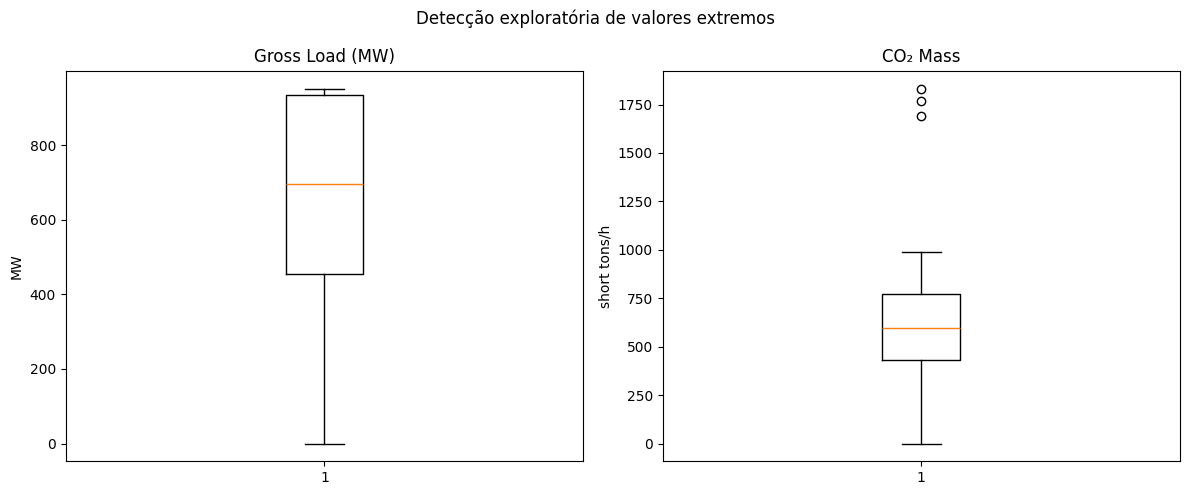


EXEMPLOS DE OBSERVAÇÕES CLASSIFICADAS COMO OUTLIER


,timestamp,Operating Time,Gross Load (MW),CO2 Mass (short tons),operational_state_basic,load_outlier_iqr,co2_outlier_iqr
4043,2025-06-18 11:00:00,1.0,939.0,1692.1,FULL_OPERATION,False,True
4044,2025-06-18 12:00:00,1.0,936.0,1832.4,FULL_OPERATION,False,True
4045,2025-06-18 13:00:00,1.0,935.0,1766.7,FULL_OPERATION,False,True



DECISÃO METODOLÓGICA

Os valores extremos foram identificados por meio do intervalo
interquartil (IQR).

Entretanto, nenhum registro foi removido ou substituído nesta
etapa.

Em uma série operacional de uma unidade termelétrica, valores
estatisticamente extremos podem representar condições reais de
operação e transição.

Assim, os indicadores de outlier são preservados como variáveis
auxiliares para análise posterior.

A eventual exclusão de observações somente deverá ocorrer caso
seja identificada evidência de erro ou inconsistência no dado.


Arquivo intermediário salvo em:
/content/drive/MyDrive/co2-cems-thermal-modeling/data/interim/step04_outlier_analysis.parquet


In [5]:
# ============================================================
# CÉLULA 4 — DETECÇÃO E ANÁLISE DE OUTLIERS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Identificar valores extremos nas principais variáveis
# numéricas da unidade:
#
#   - Gross Load (MW)
#   - CO2 Mass (short tons)
#
# A detecção de outliers faz parte das técnicas de
# pré-processamento abordadas na disciplina de Ciência de Dados.
#
# IMPORTANTE:
# ------------------------------------------------------------
# Nesta etapa os outliers serão IDENTIFICADOS, mas NÃO serão
# automaticamente removidos.
#
# Em uma unidade termelétrica, valores extremos podem representar
# fenômenos reais, por exemplo:
#
#   - startup;
#   - shutdown;
#   - rampas rápidas;
#   - operação parcial;
#   - regimes extremos de carga.
#
# Portanto, a decisão de excluir um valor deve considerar seu
# significado operacional e não apenas um critério estatístico.
#
# MÉTODO
# ------------------------------------------------------------
# Será utilizado o intervalo interquartil (IQR):
#
#       IQR = Q3 - Q1
#
# Limite inferior:
#
#       Q1 - 1.5 × IQR
#
# Limite superior:
#
#       Q3 + 1.5 × IQR
#
# A análise será feita apenas para horas em que a unidade
# está operando (Operating Time > 0).
#
# As horas OFF não entram na detecção porque os zeros criados
# anteriormente representam o estado desligado e alterariam
# artificialmente a distribuição.
# ============================================================


import matplotlib.pyplot as plt


# ============================================================
# 1. SELECIONAR HORAS OPERACIONAIS
# ============================================================

df_on = (
    df[
        df["is_on"]
    ]
    .copy()
)


print("=" * 70)
print("ANÁLISE DE OUTLIERS")
print("=" * 70)

print(
    "\nHoras operacionais analisadas:",
    f"{len(df_on):,}"
)


# ============================================================
# 2. FUNÇÃO PARA CÁLCULO DOS LIMITES PELO IQR
# ============================================================

def calculate_iqr_limits(series):

    clean_series = (
        series
        .dropna()
    )

    q1 = clean_series.quantile(
        0.25
    )

    q3 = clean_series.quantile(
        0.75
    )

    iqr = (
        q3
        -
        q1
    )

    lower_limit = (
        q1
        -
        1.5 * iqr
    )

    upper_limit = (
        q3
        +
        1.5 * iqr
    )

    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_limit": lower_limit,
        "upper_limit": upper_limit
    }


# ============================================================
# 3. CARGA
# ============================================================

load_limits = calculate_iqr_limits(
    df_on["Gross Load (MW)"]
)


df["load_outlier_iqr"] = False


load_outlier_mask = (

    df["is_on"]

    &

    (
        (
            df["Gross Load (MW)"]
            <
            load_limits["lower_limit"]
        )

        |

        (
            df["Gross Load (MW)"]
            >
            load_limits["upper_limit"]
        )
    )
)


df.loc[
    load_outlier_mask,
    "load_outlier_iqr"
] = True


# ============================================================
# 4. CO2
# ============================================================

co2_limits = calculate_iqr_limits(
    df_on["CO2 Mass (short tons)"]
)


df["co2_outlier_iqr"] = False


co2_outlier_mask = (

    df["is_on"]

    &

    (
        (
            df["CO2 Mass (short tons)"]
            <
            co2_limits["lower_limit"]
        )

        |

        (
            df["CO2 Mass (short tons)"]
            >
            co2_limits["upper_limit"]
        )
    )
)


df.loc[
    co2_outlier_mask,
    "co2_outlier_iqr"
] = True


# ============================================================
# 5. RESUMO DOS LIMITES
# ============================================================

outlier_limits = pd.DataFrame({

    "variavel": [
        "Gross Load (MW)",
        "CO2 Mass (short tons)"
    ],

    "Q1": [
        load_limits["q1"],
        co2_limits["q1"]
    ],

    "Q3": [
        load_limits["q3"],
        co2_limits["q3"]
    ],

    "IQR": [
        load_limits["iqr"],
        co2_limits["iqr"]
    ],

    "limite_inferior": [
        load_limits["lower_limit"],
        co2_limits["lower_limit"]
    ],

    "limite_superior": [
        load_limits["upper_limit"],
        co2_limits["upper_limit"]
    ]

})


print("\n" + "=" * 70)
print("LIMITES PELO MÉTODO IQR")
print("=" * 70)

display(
    outlier_limits.round(3)
)


# ============================================================
# 6. QUANTIDADE DE OUTLIERS
# ============================================================

n_load_outliers = int(
    df["load_outlier_iqr"]
    .sum()
)

n_co2_outliers = int(
    df["co2_outlier_iqr"]
    .sum()
)


outlier_summary = pd.DataFrame({

    "variavel": [
        "Gross Load (MW)",
        "CO2 Mass (short tons)"
    ],

    "outliers": [
        n_load_outliers,
        n_co2_outliers
    ],

    "percentual_horas_operacionais": [

        100
        *
        n_load_outliers
        /
        len(df_on),

        100
        *
        n_co2_outliers
        /
        len(df_on)
    ]

})


print("\n" + "=" * 70)
print("QUANTIDADE DE OUTLIERS")
print("=" * 70)

display(
    outlier_summary.round(3)
)


# ============================================================
# 7. RELAÇÃO COM O ESTADO OPERACIONAL
# ============================================================
#
# Esta análise é particularmente importante.
#
# Um valor estatisticamente extremo pode coincidir com uma
# hora de operação parcial, o que sugere que ele pode estar
# relacionado a uma transição operacional real.
# ============================================================

outliers_by_state = (

    df[
        df["is_on"]
    ]
    .groupby(
        "operational_state_basic"
    )
    .agg(

        horas=(
            "timestamp",
            "size"
        ),

        outliers_carga=(
            "load_outlier_iqr",
            "sum"
        ),

        outliers_co2=(
            "co2_outlier_iqr",
            "sum"
        )

    )
    .reset_index()
)


outliers_by_state[
    "pct_outlier_carga"
] = (

    100
    *
    outliers_by_state["outliers_carga"]
    /
    outliers_by_state["horas"]

)


outliers_by_state[
    "pct_outlier_co2"
] = (

    100
    *
    outliers_by_state["outliers_co2"]
    /
    outliers_by_state["horas"]

)


print("\n" + "=" * 70)
print("OUTLIERS POR ESTADO OPERACIONAL")
print("=" * 70)

display(
    outliers_by_state.round(3)
)


# ============================================================
# 8. BOXPLOTS
# ============================================================
#
# Visualização simples para apresentação.
#
# Os gráficos mostram a distribuição das variáveis durante as
# horas operacionais.
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


axes[0].boxplot(
    df_on[
        "Gross Load (MW)"
    ].dropna()
)

axes[0].set_title(
    "Gross Load (MW)"
)

axes[0].set_ylabel(
    "MW"
)


axes[1].boxplot(
    df_on[
        "CO2 Mass (short tons)"
    ].dropna()
)

axes[1].set_title(
    "CO₂ Mass"
)

axes[1].set_ylabel(
    "short tons/h"
)


plt.suptitle(
    "Detecção exploratória de valores extremos"
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. OBSERVAÇÕES MAIS EXTREMAS
# ============================================================
#
# Em vez de remover valores automaticamente, mostramos alguns
# dos maiores valores para permitir inspeção operacional.
# ============================================================

extreme_records = (

    df[
        df["load_outlier_iqr"]
        |
        df["co2_outlier_iqr"]
    ][
        [
            "timestamp",
            "Operating Time",
            "Gross Load (MW)",
            "CO2 Mass (short tons)",
            "operational_state_basic",
            "load_outlier_iqr",
            "co2_outlier_iqr"
        ]
    ]
    .copy()
)


print("\n" + "=" * 70)
print("EXEMPLOS DE OBSERVAÇÕES CLASSIFICADAS COMO OUTLIER")
print("=" * 70)


display(
    extreme_records
    .head(20)
)


# ============================================================
# 10. DECISÃO DE TRATAMENTO
# ============================================================

print("\n" + "=" * 70)
print("DECISÃO METODOLÓGICA")
print("=" * 70)


print(
    """
Os valores extremos foram identificados por meio do intervalo
interquartil (IQR).

Entretanto, nenhum registro foi removido ou substituído nesta
etapa.

Em uma série operacional de uma unidade termelétrica, valores
estatisticamente extremos podem representar condições reais de
operação e transição.

Assim, os indicadores de outlier são preservados como variáveis
auxiliares para análise posterior.

A eventual exclusão de observações somente deverá ocorrer caso
seja identificada evidência de erro ou inconsistência no dado.
"""
)


# ============================================================
# 11. SALVAR RESULTADO INTERMEDIÁRIO
# ============================================================

STEP4_PATH = (
    DATA_INTERIM
    /
    "step04_outlier_analysis.parquet"
)


df.to_parquet(
    STEP4_PATH,
    index=False
)


print(
    "\nArquivo intermediário salvo em:"
)

print(
    STEP4_PATH
)

In [6]:
# ============================================================
# CÉLULA 5 — FEATURE ENGINEERING ORIENTADA AO PROCESSO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Criar atributos que representem não apenas o estado atual da
# unidade, mas também sua trajetória operacional recente.
#
# FUNDAMENTAÇÃO
# ------------------------------------------------------------
# Feature engineering faz parte das técnicas de pré-processamento
# abordadas nas disciplinas.
#
# O problema deste trabalho possui natureza temporal e
# operacional.
#
# A hipótese futura de modelagem é:
#
#   informações sobre estados e transições operacionais podem
#   contribuir para estimar CO2 além da informação fornecida
#   apenas pela carga instantânea.
#
#
# IMPORTANTE — EVITAR TARGET LEAKAGE
# ------------------------------------------------------------
# CO2 Mass é a variável-alvo.
#
# Portanto, NÃO serão construídas features baseadas em:
#
#   - CO2 da hora anterior;
#   - médias móveis de CO2;
#   - CO2 futuro;
#   - qualquer transformação derivada da variável-alvo.
#
# As features serão construídas exclusivamente a partir de
# informações operacionais disponíveis.
# ============================================================


# ============================================================
# 1. GARANTIR ORDENAÇÃO TEMPORAL
# ============================================================

df = (
    df
    .sort_values("timestamp")
    .reset_index(drop=True)
)


# ============================================================
# 2. CARGA INSTANTÂNEA
# ============================================================
#
# Esta será a principal variável de referência.
#
# Ela representa o cenário mais simples:
#
#       CO2 = f(carga atual)
#
# ============================================================

df["load_current_mw"] = (
    df["gross_load_mw_treated"]
)


# ============================================================
# 3. CARGA DA HORA ANTERIOR
# ============================================================
#
# P(t-1)
#
# Introduz informação sobre a trajetória imediatamente anterior
# da unidade.
# ============================================================

df["load_lag_1h"] = (
    df["load_current_mw"]
    .shift(1)
)


# ============================================================
# 4. VARIAÇÃO HORÁRIA DA CARGA
# ============================================================
#
# ΔP(t) = P(t) - P(t-1)
#
# Interpretação:
#
#   ΔP > 0  → aumento de carga
#   ΔP < 0  → redução de carga
#   ΔP ≈ 0  → operação aproximadamente estável
#
# Essa feature é importante para representar rampas.
# ============================================================

df["delta_load_1h"] = (
    df["load_current_mw"]
    -
    df["load_lag_1h"]
)


# ============================================================
# 5. MÓDULO DA VARIAÇÃO DE CARGA
# ============================================================
#
# |ΔP|
#
# Mede a intensidade da mudança independentemente da direção.
# ============================================================

df["abs_delta_load_1h"] = (
    df["delta_load_1h"]
    .abs()
)


# ============================================================
# 6. MÉDIA DA CARGA NAS 3 HORAS ANTERIORES
# ============================================================
#
# Essa variável resume o histórico operacional recente.
#
# IMPORTANTE:
# usamos shift(1) antes da média móvel para que a carga da hora
# atual não seja incluída duas vezes no histórico.
# ============================================================

df["load_mean_previous_3h"] = (

    df["load_current_mw"]
    .shift(1)
    .rolling(
        window=3,
        min_periods=1
    )
    .mean()

)


# ============================================================
# 7. OPERATING TIME DA HORA ANTERIOR
# ============================================================

df["operating_time_lag_1h"] = (
    df["Operating Time"]
    .shift(1)
)


# ============================================================
# 8. IDENTIFICAR STARTUP E SHUTDOWN
# ============================================================
#
# Startup:
#
#       OFF → ON
#
# Shutdown:
#
#       ON → OFF
#
# A primeira observação do ano NÃO é considerada automaticamente
# uma transição, pois o estado de 31/12/2024 não está disponível.
# ============================================================

previous_on = (
    df["is_on"]
    .shift(1)
)


startup_event = (

    df["is_on"]

    &

    previous_on.eq(False)

)


shutdown_event = (

    df["is_off"]

    &

    previous_on.eq(True)

)


df["startup_event"] = (
    startup_event
)

df["shutdown_event"] = (
    shutdown_event
)


# ============================================================
# 9. DIREÇÃO OPERACIONAL
# ============================================================
#
# Criamos uma classificação simples baseada no sinal de ΔP.
#
# Ainda NÃO estamos definindo formalmente estados como
# LOW LOAD / HIGH LOAD ou utilizando limiares arbitrários.
# ============================================================

conditions = [

    df["is_off"],

    (
        df["is_on"]
        &
        (df["delta_load_1h"] > 0)
    ),

    (
        df["is_on"]
        &
        (df["delta_load_1h"] < 0)
    ),

    (
        df["is_on"]
        &
        (df["delta_load_1h"] == 0)
    )
]


choices = [

    "OFF",

    "LOAD_INCREASE",

    "LOAD_DECREASE",

    "STABLE_LOAD"
]


df["load_direction"] = np.select(

    conditions,

    choices,

    default="UNDEFINED"

)


# ============================================================
# 10. TEMPO DESDE O ÚLTIMO STARTUP
# ============================================================
#
# Esta variável representa há quantas horas a unidade está
# operando desde a última transição OFF → ON.
#
# Pode ser útil futuramente para representar efeitos associados
# ao início de um ciclo operacional.
#
# Durante períodos OFF o valor é zero.
# ============================================================

hours_since_startup = []

counter = 0


for is_on_value, startup_value in zip(

    df["is_on"],
    df["startup_event"]

):

    if not is_on_value:

        counter = 0

        hours_since_startup.append(
            0
        )

    else:

        if startup_value:

            counter = 1

        elif counter > 0:

            counter += 1

        else:

            # A unidade pode já estar ligada no início do ano.
            counter = 0

        hours_since_startup.append(
            counter
        )


df["hours_since_startup"] = (
    hours_since_startup
)


# ============================================================
# 11. VARIÁVEIS TEMPORAIS SIMPLES
# ============================================================
#
# Hora do dia e mês podem capturar padrões temporais de
# operação.
#
# Neste momento elas são criadas apenas para caracterização.
# A decisão de utilizá-las em um modelo será feita depois.
# ============================================================

df["hour_of_day"] = (
    df["timestamp"]
    .dt.hour
)

df["month"] = (
    df["timestamp"]
    .dt.month
)


# ============================================================
# 12. RESUMO DAS FEATURES CRIADAS
# ============================================================

engineered_features = [

    "load_current_mw",

    "load_lag_1h",

    "delta_load_1h",

    "abs_delta_load_1h",

    "load_mean_previous_3h",

    "operating_time_lag_1h",

    "startup_event",

    "shutdown_event",

    "load_direction",

    "hours_since_startup",

    "hour_of_day",

    "month"
]


feature_summary = pd.DataFrame({

    "feature":
        engineered_features,

    "tipo":
        [
            str(df[col].dtype)
            for col in engineered_features
        ],

    "ausentes":
        [
            int(
                df[col]
                .isna()
                .sum()
            )
            for col in engineered_features
        ]

})


print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

display(
    feature_summary
)


# ============================================================
# 13. RESUMO DAS TRANSIÇÕES
# ============================================================

n_startups = int(
    df["startup_event"]
    .sum()
)

n_shutdowns = int(
    df["shutdown_event"]
    .sum()
)


print("\n" + "=" * 70)
print("TRANSIÇÕES OPERACIONAIS")
print("=" * 70)

print(
    "Startups observados:",
    n_startups
)

print(
    "Shutdowns observados:",
    n_shutdowns
)


# ============================================================
# 14. DISTRIBUIÇÃO DA DIREÇÃO DE CARGA
# ============================================================

load_direction_summary = (

    df[
        "load_direction"
    ]
    .value_counts()
    .rename_axis(
        "direcao"
    )
    .reset_index(
        name="horas"
    )

)


load_direction_summary[
    "percentual"
] = (

    100
    *
    load_direction_summary["horas"]
    /
    len(df)

)


print("\n" + "=" * 70)
print("COMPORTAMENTO DA CARGA")
print("=" * 70)

display(
    load_direction_summary
    .round(3)
)


# ============================================================
# 15. EXEMPLO DE UMA TRANSIÇÃO DE STARTUP
# ============================================================

startup_indices = (
    df.index[
        df["startup_event"]
    ]
    .tolist()
)


if len(startup_indices) > 0:

    example_index = (
        startup_indices[0]
    )

    start = max(
        0,
        example_index - 3
    )

    end = min(
        len(df),
        example_index + 8
    )


    example_columns = [

        "timestamp",

        "Operating Time",

        "load_current_mw",

        "load_lag_1h",

        "delta_load_1h",

        "startup_event",

        "load_direction",

        "hours_since_startup",

        "CO2 Mass (short tons)"
    ]


    print(
        "\n" + "=" * 70
    )

    print(
        "EXEMPLO DE STARTUP"
    )

    print(
        "=" * 70
    )


    display(

        df.loc[
            start:end,
            example_columns
        ]

    )


# ============================================================
# 16. SALVAR RESULTADO INTERMEDIÁRIO
# ============================================================

STEP5_PATH = (

    DATA_INTERIM
    /
    "step05_feature_engineering.parquet"

)


df.to_parquet(

    STEP5_PATH,

    index=False

)


print("\n" + "=" * 70)
print("ETAPA 5 CONCLUÍDA")
print("=" * 70)

print(
    "\nArquivo intermediário:"
)

print(
    STEP5_PATH
)


# ============================================================
# 17. INTERPRETAÇÃO METODOLÓGICA
# ============================================================

print(
    """
A engenharia de atributos transformou a série horária original
em uma representação que incorpora informações sobre a
trajetória operacional da unidade.

Além da carga instantânea, passaram a ser representados:

- carga anterior;
- variação horária da carga;
- intensidade da variação;
- histórico recente de carga;
- transições de startup e shutdown;
- tempo desde o último startup;
- direção da mudança de carga.

Nenhuma variável derivada de CO2 foi utilizada como atributo
preditivo, evitando vazamento de informação da variável-alvo.

Essa estrutura permitirá posteriormente comparar uma abordagem
baseada apenas na carga atual com uma abordagem que incorpora
informações sobre o comportamento operacional do processo.
"""
)

FEATURE ENGINEERING


,feature,tipo,ausentes
0,load_current_mw,float64,0
1,load_lag_1h,float64,1
2,delta_load_1h,float64,1
3,abs_delta_load_1h,float64,1
4,load_mean_previous_3h,float64,1
5,operating_time_lag_1h,float64,1
6,startup_event,bool,0
7,shutdown_event,bool,0
8,load_direction,object,0
9,hours_since_startup,int64,0



TRANSIÇÕES OPERACIONAIS
Startups observados: 38
Shutdowns observados: 37

COMPORTAMENTO DA CARGA


,direcao,horas,percentual
0,LOAD_INCREASE,2701,30.833
1,OFF,2511,28.664
2,LOAD_DECREASE,2375,27.112
3,STABLE_LOAD,1173,13.390



EXEMPLO DE STARTUP


,timestamp,Operating Time,load_current_mw,load_lag_1h,delta_load_1h,startup_event,load_direction,hours_since_startup,CO2 Mass (short tons)
13,2025-01-01 13:00:00,0.00,0.0,0.0,0.0,False,OFF,0,NaN
14,2025-01-01 14:00:00,0.00,0.0,0.0,0.0,False,OFF,0,NaN
15,2025-01-01 15:00:00,0.00,0.0,0.0,0.0,False,OFF,0,NaN
16,2025-01-01 16:00:00,0.72,0.0,0.0,0.0,True,STABLE_LOAD,1,26.352
17,2025-01-01 17:00:00,1.00,0.0,0.0,0.0,False,STABLE_LOAD,2,54.700
18,2025-01-01 18:00:00,1.00,0.0,0.0,0.0,False,STABLE_LOAD,3,54.900
19,2025-01-01 19:00:00,1.00,0.0,0.0,0.0,False,STABLE_LOAD,4,55.300
20,2025-01-01 20:00:00,1.00,0.0,0.0,0.0,False,STABLE_LOAD,5,51.800
21,2025-01-01 21:00:00,1.00,0.0,0.0,0.0,False,STABLE_LOAD,6,46.900
22,2025-01-01 22:00:00,1.00,33.0,0.0,33.0,False,LOAD_INCREASE,7,109.400



ETAPA 5 CONCLUÍDA

Arquivo intermediário:
/content/drive/MyDrive/co2-cems-thermal-modeling/data/interim/step05_feature_engineering.parquet

A engenharia de atributos transformou a série horária original
em uma representação que incorpora informações sobre a
trajetória operacional da unidade.

Além da carga instantânea, passaram a ser representados:

- carga anterior;
- variação horária da carga;
- intensidade da variação;
- histórico recente de carga;
- transições de startup e shutdown;
- tempo desde o último startup;
- direção da mudança de carga.

Nenhuma variável derivada de CO2 foi utilizada como atributo
preditivo, evitando vazamento de informação da variável-alvo.

Essa estrutura permitirá posteriormente comparar uma abordagem
baseada apenas na carga atual com uma abordagem que incorpora
informações sobre o comportamento operacional do processo.



PCA — PREPARAÇÃO DOS DADOS

Horas operacionais disponíveis: 6,249

Valores ausentes por feature:


,ausentes
load_current_mw,0
load_lag_1h,0
delta_load_1h,0
abs_delta_load_1h,0
load_mean_previous_3h,0
operating_time_lag_1h,0
hours_since_startup,0



Observações utilizadas na PCA: 6,249
Observações excluídas apenas por ausência: 0

VARIÂNCIA EXPLICADA PELA PCA


,componente,variancia_explicada_pct,variancia_acumulada_pct
0,PC1,44.07,44.07
1,PC2,16.51,60.57
2,PC3,14.15,74.72
3,PC4,13.27,87.99
4,PC5,11.66,99.65
5,PC6,0.35,100.00
6,PC7,0.00,100.00



Componentes necessárias para explicar pelo menos 90% da variância: 5
Total de features analisadas: 7


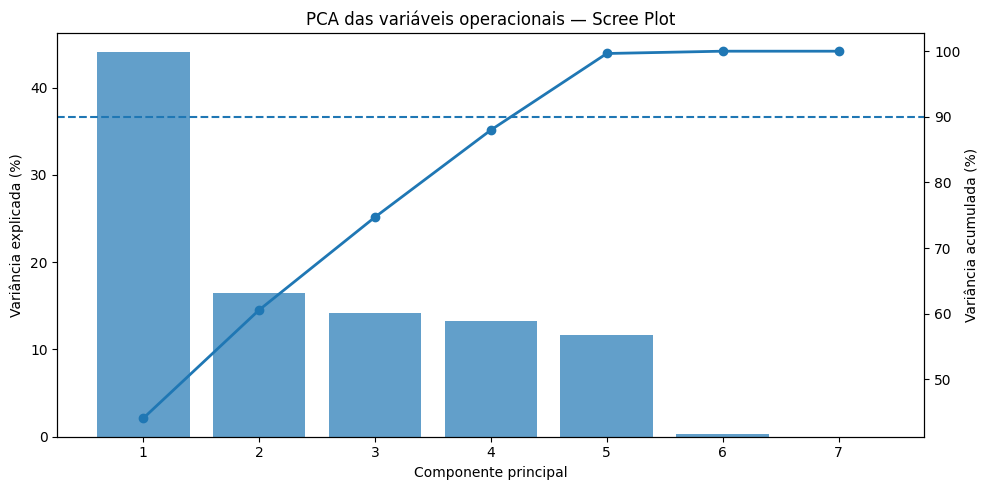


LOADINGS DAS COMPONENTES PRINCIPAIS


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
load_current_mw,0.539,0.225,0.028,-0.151,-0.157,-0.364,-0.692
load_lag_1h,0.561,0.024,-0.093,-0.130,-0.048,-0.414,0.697
delta_load_1h,-0.096,0.742,0.449,-0.073,-0.400,0.197,0.188
abs_delta_load_1h,-0.007,-0.611,0.497,-0.353,-0.504,0.012,0.000
load_mean_previous_3h,0.555,-0.060,-0.149,-0.095,0.004,0.811,-0.000
operating_time_lag_1h,0.203,-0.037,0.712,0.118,0.661,-0.000,0.000
hours_since_startup,0.192,-0.140,0.114,0.899,-0.350,-0.014,-0.000



MAIORES CONTRIBUIÇÕES PARA PC1


,|loading PC1|
load_lag_1h,0.560507
load_mean_previous_3h,0.554709
load_current_mw,0.539064
operating_time_lag_1h,0.203078
hours_since_startup,0.192500
delta_load_1h,0.095857
abs_delta_load_1h,0.007412



MAIORES CONTRIBUIÇÕES PARA PC2


,|loading PC2|
delta_load_1h,0.742062
abs_delta_load_1h,0.611174
load_current_mw,0.225093
hours_since_startup,0.139993
load_mean_previous_3h,0.060483
operating_time_lag_1h,0.036532
load_lag_1h,0.023514


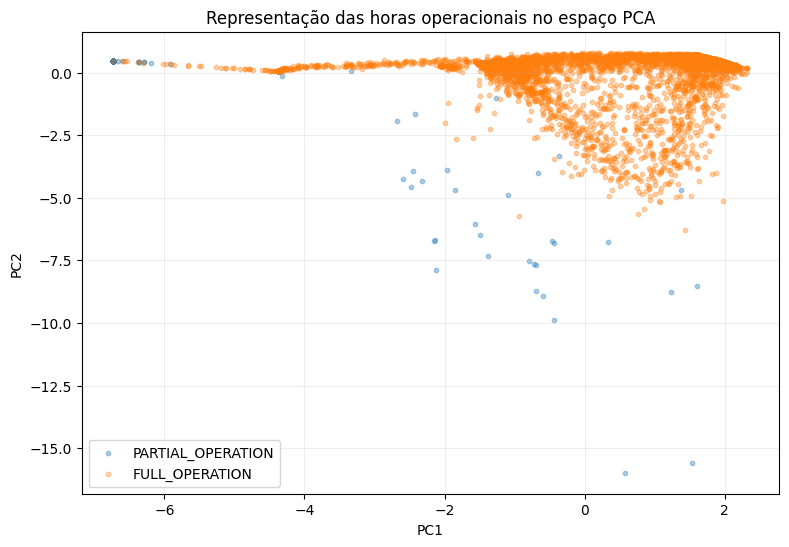


INTERPRETAÇÃO PARA O TRABALHO

Foram analisadas 7 variáveis operacionais
por meio de Análise de Componentes Principais (PCA).

São necessárias 5 componentes para explicar
pelo menos 90% da variância observada.

A PCA foi utilizada nesta etapa como ferramenta exploratória
para avaliar redundância entre as características criadas.

As variáveis originais não foram substituídas pelas componentes
principais neste momento.

Essa decisão preserva a interpretabilidade física das variáveis
operacionais enquanto permite avaliar quantitativamente o
potencial de redução de dimensionalidade.


Resultados salvos em:
/content/drive/MyDrive/co2-cems-thermal-modeling/outputs/tables/pca_variance_explained.csv
/content/drive/MyDrive/co2-cems-thermal-modeling/outputs/tables/pca_loadings.csv


In [7]:
# ============================================================
# CÉLULA 6 — PCA EXPLORATÓRIA DAS VARIÁVEIS OPERACIONAIS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Aplicar Análise de Componentes Principais (PCA), técnica
# apresentada na Aula 3 de Modelagem Matemática com IA, para
# investigar a estrutura das variáveis criadas por meio de
# feature engineering.
#
# A pergunta desta etapa é:
#
#   As variáveis que representam o comportamento operacional
#   carregam informações muito redundantes entre si?
#
# A PCA será utilizada APENAS como ferramenta exploratória.
#
# Nenhuma variável será removida ou substituída automaticamente.
#
#
# IMPORTANTE
# ------------------------------------------------------------
# CO2 Mass NÃO participa da PCA.
#
# O CO2 é a variável-alvo do problema e sua inclusão na redução
# de dimensionalidade das variáveis explicativas provocaria
# vazamento de informação (target leakage).
#
#
# ESCOPO DA PCA
# ------------------------------------------------------------
# A análise será realizada somente nas horas em que a unidade
# está operando.
#
# Motivo:
#
#   Nas horas OFF, muitas variáveis operacionais assumem zero.
#   A inclusão das 2.511 horas desligadas poderia fazer a PCA
#   representar principalmente a diferença ON/OFF, enquanto
#   nosso interesse é investigar a variabilidade do processo
#   DURANTE a operação.
#
#
# VARIÁVEIS CONSIDERADAS
# ------------------------------------------------------------
#
#   load_current_mw
#       carga atual
#
#   load_lag_1h
#       carga da hora anterior
#
#   delta_load_1h
#       variação horária da carga
#
#   abs_delta_load_1h
#       intensidade da variação
#
#   load_mean_previous_3h
#       histórico recente de carga
#
#   operating_time_lag_1h
#       condição operacional anterior
#
#   hours_since_startup
#       duração do ciclo operacional atual
#
#
# Variáveis como mês e hora do dia não entram nesta PCA porque
# representam informação temporal/calendário, e não diretamente
# o estado físico do processo.
# ============================================================


# ============================================================
# 1. IMPORTAÇÕES
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt


# ============================================================
# 2. DEFINIR AS FEATURES OPERACIONAIS
# ============================================================

pca_features = [

    "load_current_mw",

    "load_lag_1h",

    "delta_load_1h",

    "abs_delta_load_1h",

    "load_mean_previous_3h",

    "operating_time_lag_1h",

    "hours_since_startup"

]


# ============================================================
# 3. SELECIONAR SOMENTE HORAS OPERACIONAIS
# ============================================================

pca_data = (

    df.loc[
        df["is_on"],
        pca_features
    ]

    .copy()

)


# ============================================================
# 4. VERIFICAR DADOS AUSENTES
# ============================================================
#
# PCA não aceita valores ausentes.
#
# Não faremos imputação automaticamente.
#
# Caso exista alguma observação incompleta em razão das
# operações de lag, ela será apenas excluída desta análise
# exploratória específica.
# ============================================================

rows_before = len(
    pca_data
)


missing_by_feature = (

    pca_data
    .isna()
    .sum()

)


print("=" * 70)
print("PCA — PREPARAÇÃO DOS DADOS")
print("=" * 70)


print(
    "\nHoras operacionais disponíveis:",
    f"{rows_before:,}"
)


print(
    "\nValores ausentes por feature:"
)

display(
    missing_by_feature
    .rename("ausentes")
    .to_frame()
)


pca_data = (

    pca_data
    .dropna()
    .copy()

)


rows_after = len(
    pca_data
)


print(
    "\nObservações utilizadas na PCA:",
    f"{rows_after:,}"
)

print(
    "Observações excluídas apenas por ausência:",
    rows_before - rows_after
)


# ============================================================
# 5. PADRONIZAÇÃO
# ============================================================
#
# A PCA é sensível à escala das variáveis.
#
# As features possuem unidades e amplitudes muito diferentes:
#
#   MW
#   MW/h
#   horas
#   fração de hora
#
# Portanto, antes da PCA, aplicamos padronização:
#
#                x - média
#       z = -------------------
#              desvio-padrão
#
# Essa etapa corresponde ao mesmo princípio do exemplo da
# disciplina, em que a PCA foi executada com centralização
# e reescala das variáveis.
# ============================================================

scaler_pca = StandardScaler()


X_scaled = scaler_pca.fit_transform(
    pca_data
)


# ============================================================
# 6. PCA
# ============================================================
#
# Inicialmente mantemos todas as componentes.
#
# Assim podemos avaliar quanta variância é explicada por cada
# uma antes de decidir se existe justificativa para redução de
# dimensionalidade.
# ============================================================

pca = PCA()


X_pca = pca.fit_transform(
    X_scaled
)


# ============================================================
# 7. VARIÂNCIA EXPLICADA
# ============================================================

explained_variance = (
    pca.explained_variance_ratio_
)


cumulative_variance = (
    explained_variance
    .cumsum()
)


pca_variance_table = pd.DataFrame({

    "componente": [

        f"PC{i}"

        for i in range(
            1,
            len(explained_variance) + 1
        )

    ],

    "variancia_explicada_pct":

        explained_variance
        * 100,

    "variancia_acumulada_pct":

        cumulative_variance
        * 100

})


print("\n" + "=" * 70)
print("VARIÂNCIA EXPLICADA PELA PCA")
print("=" * 70)


display(
    pca_variance_table
    .round(2)
)


# ============================================================
# 8. QUANTAS COMPONENTES EXPLICAM 90% DA VARIÂNCIA?
# ============================================================
#
# O limiar de 90% é utilizado aqui apenas como referência
# exploratória.
#
# Ele NÃO é uma regra automática para seleção.
# ============================================================

n_components_90 = (

    np.argmax(
        cumulative_variance
        >= 0.90
    )

    + 1

)


print(
    "\nComponentes necessárias para explicar "
    "pelo menos 90% da variância:",
    n_components_90
)

print(
    "Total de features analisadas:",
    len(pca_features)
)


# ============================================================
# 9. SCREE PLOT
# ============================================================
#
# O gráfico mostra:
#
#   - variância explicada por cada componente;
#   - variância acumulada.
#
# Esse é um resultado visual particularmente útil para a
# apresentação do Trabalho 1.
# ============================================================

components = np.arange(
    1,
    len(explained_variance) + 1
)


fig, ax1 = plt.subplots(
    figsize=(10, 5)
)


ax1.bar(

    components,

    explained_variance * 100,

    alpha=0.7,

    label="Variância individual"

)


ax1.set_xlabel(
    "Componente principal"
)

ax1.set_ylabel(
    "Variância explicada (%)"
)

ax1.set_xticks(
    components
)


ax2 = ax1.twinx()


ax2.plot(

    components,

    cumulative_variance * 100,

    marker="o",

    linewidth=2,

    label="Variância acumulada"

)


ax2.axhline(

    90,

    linestyle="--",

    linewidth=1.5,

    label="Referência de 90%"

)


ax2.set_ylabel(
    "Variância acumulada (%)"
)


plt.title(
    "PCA das variáveis operacionais — Scree Plot"
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. LOADINGS DAS COMPONENTES
# ============================================================
#
# Os loadings mostram quanto cada variável original contribui
# para cada componente principal.
#
# Isso ajuda a interpretar fisicamente as componentes.
#
# Por exemplo:
#
# uma componente pode estar fortemente associada ao nível de
# carga, enquanto outra pode representar variações/rampas.
# ============================================================

loadings = pd.DataFrame(

    pca.components_.T,

    index=pca_features,

    columns=[

        f"PC{i}"

        for i in range(
            1,
            len(pca_features) + 1
        )

    ]

)


print("\n" + "=" * 70)
print("LOADINGS DAS COMPONENTES PRINCIPAIS")
print("=" * 70)


display(
    loadings
    .round(3)
)


# ============================================================
# 11. VARIÁVEIS MAIS ASSOCIADAS À PC1 E PC2
# ============================================================

pc1_importance = (

    loadings["PC1"]
    .abs()
    .sort_values(
        ascending=False
    )

)


pc2_importance = (

    loadings["PC2"]
    .abs()
    .sort_values(
        ascending=False
    )

)


print("\n" + "=" * 70)
print("MAIORES CONTRIBUIÇÕES PARA PC1")
print("=" * 70)

display(
    pc1_importance
    .rename(
        "|loading PC1|"
    )
    .to_frame()
)


print("\n" + "=" * 70)
print("MAIORES CONTRIBUIÇÕES PARA PC2")
print("=" * 70)

display(
    pc2_importance
    .rename(
        "|loading PC2|"
    )
    .to_frame()
)


# ============================================================
# 12. REPRESENTAÇÃO DAS OBSERVAÇÕES EM PC1 × PC2
# ============================================================
#
# Este gráfico permite observar se diferentes comportamentos
# operacionais aparecem organizados no espaço das componentes.
#
# Para não poluir o gráfico, usamos apenas uma amostra visual
# se houver muitas observações.
# ============================================================

pca_scores = pd.DataFrame(

    X_pca[:, :2],

    columns=[
        "PC1",
        "PC2"
    ],

    index=pca_data.index

)


pca_scores[
    "operational_state"
] = (

    df.loc[
        pca_scores.index,
        "operational_state_basic"
    ]

)


plt.figure(
    figsize=(9, 6)
)


for state in (

    pca_scores[
        "operational_state"
    ]
    .unique()

):

    subset = (

        pca_scores[
            pca_scores[
                "operational_state"
            ]
            ==
            state
        ]

    )


    plt.scatter(

        subset["PC1"],

        subset["PC2"],

        s=10,

        alpha=0.35,

        label=state

    )


plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.title(
    "Representação das horas operacionais no espaço PCA"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.show()


# ============================================================
# 13. DECISÃO EXPLORATÓRIA
# ============================================================
#
# Neste momento NÃO transformamos o dataset principal para PCA.
#
# A decisão depende dos resultados obtidos.
# ============================================================

print("\n" + "=" * 70)
print("INTERPRETAÇÃO PARA O TRABALHO")
print("=" * 70)


print(
    f"""
Foram analisadas {len(pca_features)} variáveis operacionais
por meio de Análise de Componentes Principais (PCA).

São necessárias {n_components_90} componentes para explicar
pelo menos 90% da variância observada.

A PCA foi utilizada nesta etapa como ferramenta exploratória
para avaliar redundância entre as características criadas.

As variáveis originais não foram substituídas pelas componentes
principais neste momento.

Essa decisão preserva a interpretabilidade física das variáveis
operacionais enquanto permite avaliar quantitativamente o
potencial de redução de dimensionalidade.
"""
)


# ============================================================
# 14. SALVAR RESULTADOS DA PCA
# ============================================================

PCA_VARIANCE_PATH = (

    TABLES
    /
    "pca_variance_explained.csv"

)


PCA_LOADINGS_PATH = (

    TABLES
    /
    "pca_loadings.csv"

)


pca_variance_table.to_csv(

    PCA_VARIANCE_PATH,

    index=False

)


loadings.to_csv(

    PCA_LOADINGS_PATH

)


print(
    "\nResultados salvos em:"
)

print(
    PCA_VARIANCE_PATH
)

print(
    PCA_LOADINGS_PATH
)

In [8]:
# ============================================================
# CÉLULA 7 — FECHAMENTO DA PCA E PREPARAÇÃO EXPERIMENTAL
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Esta etapa possui dois objetivos:
#
#   1. registrar a interpretação e a decisão metodológica
#      resultantes da PCA realizada na etapa anterior;
#
#   2. preparar a base para as futuras etapas de modelagem,
#      realizando a separação temporal dos dados e a
#      normalização das variáveis explicativas.
#
#
# ============================================================
# 1. INTERPRETAÇÃO DOS RESULTADOS DA PCA
# ============================================================
#
# Na etapa anterior foram analisadas sete variáveis operacionais:
#
#   - load_current_mw
#   - load_lag_1h
#   - delta_load_1h
#   - abs_delta_load_1h
#   - load_mean_previous_3h
#   - operating_time_lag_1h
#   - hours_since_startup
#
# Os resultados mostraram:
#
#   PC1  = 44,07% da variância
#   PC2  = 16,51%
#   PC3  = 14,15%
#   PC4  = 13,27%
#   PC5  = 11,66%
#
# Variância acumulada:
#
#   PC1–PC2 = 60,57%
#   PC1–PC3 = 74,72%
#   PC1–PC4 = 87,99%
#   PC1–PC5 = 99,65%
#
# Portanto, foram necessárias CINCO componentes para representar
# pelo menos 90% da variância das sete features analisadas.
#
#
# INTERPRETAÇÃO FÍSICA
# ------------------------------------------------------------
#
# Os loadings indicaram que:
#
# PC1 está fortemente relacionada ao NÍVEL DE CARGA:
#
#   load_lag_1h             ≈ 0,561
#   load_mean_previous_3h   ≈ 0,555
#   load_current_mw         ≈ 0,539
#
# Assim, a primeira componente sintetiza principalmente o nível
# de potência recente da unidade.
#
#
# PC2 está fortemente relacionada à DINÂMICA DA CARGA:
#
#   delta_load_1h       ≈ 0,742
#   abs_delta_load_1h   ≈ 0,611
#
# Portanto, a segunda componente está associada principalmente
# às rampas e variações operacionais.
#
#
# A PCA também identificou uma forte redundância matemática.
#
# A última componente apresentou variância praticamente nula.
#
# Isso é coerente com a relação:
#
#       delta_load_1h =
#       load_current_mw - load_lag_1h
#
# Portanto, parte da redundância detectada não é um problema
# da base, mas consequência da própria engenharia de atributos.
#
#
# DECISÃO METODOLÓGICA
# ------------------------------------------------------------
#
# Apesar de a PCA revelar relações relevantes entre as features,
# a redução dimensional não foi considerada suficientemente
# expressiva para justificar a substituição das variáveis
# operacionais originais pelas componentes principais:
#
#       7 features → 5 componentes para >= 90% da variância
#
# Essa redução seria relativamente pequena e diminuiria a
# interpretabilidade física das variáveis.
#
# Dessa forma:
#
#   A PCA será mantida como ANÁLISE EXPLORATÓRIA.
#
#   As componentes principais NÃO serão utilizadas como
#   substitutas das variáveis originais nesta fase.
#
# Essa decisão permite preservar variáveis fisicamente
# interpretáveis, como carga, rampa e tempo desde startup.
#
# ============================================================


print("=" * 70)
print("CONCLUSÃO DA PCA")
print("=" * 70)

print(
    """
A PCA mostrou que existe redundância entre algumas das variáveis
operacionais, principalmente aquelas relacionadas ao nível de
carga.

Entretanto, cinco das sete componentes foram necessárias para
representar pelo menos 90% da variância.

Assim, a redução dimensional seria relativamente pequena frente
à perda de interpretabilidade física decorrente da substituição
das variáveis originais pelas componentes principais.

A PCA será mantida como ferramenta exploratória, mas as features
operacionais originais serão preservadas para as etapas futuras
de modelagem.

A análise também mostrou uma organização física interessante:

PC1 → nível de carga;
PC2 → dinâmica/rampas da carga.

Além disso, a componente de variância praticamente nula é
compatível com a dependência matemática existente entre carga
atual, carga anterior e variação da carga.
"""
)


# ============================================================
# 2. DEFINIÇÃO DO PROBLEMA EXPERIMENTAL
# ============================================================
#
# A variável que futuramente deverá ser estimada é:
#
#       CO2 Mass (short tons)
#
# Portanto:
#
#       y = emissão horária de CO2
#
#
# As variáveis explicativas serão construídas a partir das
# informações operacionais.
#
# Neste momento serão consideradas somente horas em que a
# unidade está operando.
#
# Motivo:
#
# Durante as horas OFF:
#
#   carga = 0
#   CO2 = 0 na variável tratada
#
# A inclusão dessas horas poderia aumentar artificialmente o
# desempenho de um modelo, pois prever zero durante desligamento
# é um problema muito mais simples do que estimar emissões
# durante a operação.
#
# Assim, o problema principal de modelagem será:
#
#       estimar CO2 DURANTE A OPERAÇÃO da unidade.
#
# ============================================================


model_data = (

    df[
        df["is_on"]
    ]
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)

)


# ============================================================
# 3. FEATURES CANDIDATAS
# ============================================================
#
# Mantemos features fisicamente interpretáveis.
#
# CO2 não aparece entre as variáveis explicativas, evitando
# target leakage.
# ============================================================

model_features = [

    "load_current_mw",

    "load_lag_1h",

    "delta_load_1h",

    "abs_delta_load_1h",

    "load_mean_previous_3h",

    "operating_time_lag_1h",

    "hours_since_startup"

]


target = (
    "CO2 Mass (short tons)"
)


# ============================================================
# 4. REMOVER SOMENTE LINHAS INCOMPLETAS PARA O EXPERIMENTO
# ============================================================

model_columns = (
    ["timestamp"]
    +
    model_features
    +
    [target]
)


model_data = (

    model_data[
        model_columns
    ]
    .dropna()
    .copy()

)


print("\n" + "=" * 70)
print("BASE EXPERIMENTAL")
print("=" * 70)

print(
    "\nObservações operacionais disponíveis:",
    f"{len(model_data):,}"
)

print(
    "Número de features:",
    len(model_features)
)

print(
    "Variável-alvo:",
    target
)


# ============================================================
# 5. DIVISÃO TEMPORAL
# ============================================================
#
# A base representa uma série temporal.
#
# Portanto, NÃO será utilizado train_test_split aleatório.
#
# Uma divisão aleatória permitiria que observações futuras
# participassem do treinamento utilizado para prever observações
# do passado, o que não representa um cenário operacional real.
#
# A separação adotada preserva a ordem cronológica:
#
#   TREINO
#       janeiro → setembro
#
#   VALIDAÇÃO
#       outubro
#
#   TESTE
#       novembro → dezembro
#
# A lógica é:
#
#       passado → treinamento
#
#       futuro → avaliação
#
# ============================================================


train_end = pd.Timestamp(
    f"{selected_unit['year']}-09-30 23:00:00"
)

validation_end = pd.Timestamp(
    f"{selected_unit['year']}-10-31 23:00:00"
)


train_data = (

    model_data[
        model_data["timestamp"]
        <=
        train_end
    ]
    .copy()

)


validation_data = (

    model_data[
        (
            model_data["timestamp"]
            >
            train_end
        )
        &
        (
            model_data["timestamp"]
            <=
            validation_end
        )
    ]
    .copy()

)


test_data = (

    model_data[
        model_data["timestamp"]
        >
        validation_end
    ]
    .copy()

)


# ============================================================
# 6. SEPARAÇÃO ENTRE X E y
# ============================================================

X_train = (
    train_data[
        model_features
    ]
    .copy()
)

y_train = (
    train_data[
        target
    ]
    .copy()
)


X_validation = (
    validation_data[
        model_features
    ]
    .copy()
)

y_validation = (
    validation_data[
        target
    ]
    .copy()
)


X_test = (
    test_data[
        model_features
    ]
    .copy()
)

y_test = (
    test_data[
        target
    ]
    .copy()
)


# ============================================================
# 7. RESUMO DA DIVISÃO TEMPORAL
# ============================================================

split_summary = pd.DataFrame({

    "conjunto": [
        "Treino",
        "Validação",
        "Teste"
    ],

    "inicio": [

        train_data[
            "timestamp"
        ].min(),

        validation_data[
            "timestamp"
        ].min(),

        test_data[
            "timestamp"
        ].min()
    ],

    "fim": [

        train_data[
            "timestamp"
        ].max(),

        validation_data[
            "timestamp"
        ].max(),

        test_data[
            "timestamp"
        ].max()
    ],

    "observacoes": [

        len(train_data),

        len(validation_data),

        len(test_data)
    ]

})


split_summary[
    "percentual"
] = (

    100
    *
    split_summary[
        "observacoes"
    ]
    /
    len(model_data)

)


print("\n" + "=" * 70)
print("DIVISÃO TEMPORAL")
print("=" * 70)

display(
    split_summary.round(2)
)


# ============================================================
# 8. NORMALIZAÇÃO MIN–MAX
# ============================================================
#
# A normalização Min–Max foi uma das técnicas de preparação
# estudadas na disciplina.
#
# Transformação:
#
#             x - xmin
#     x' = ---------------
#            xmax - xmin
#
# Em geral, os valores do conjunto de treinamento passam para
# uma escala aproximadamente entre 0 e 1.
#
#
# IMPORTANTE — EVITAR DATA LEAKAGE
# ------------------------------------------------------------
#
# O scaler é ajustado SOMENTE utilizando o conjunto de treino.
#
#       fit → treino
#
# Depois, o mesmo scaler é utilizado para transformar:
#
#       treino
#       validação
#       teste
#
# Se o scaler fosse ajustado utilizando o ano inteiro, valores
# futuros influenciariam a transformação dos dados de treino.
# ============================================================


from sklearn.preprocessing import MinMaxScaler


minmax_scaler = MinMaxScaler()


X_train_scaled = (
    minmax_scaler
    .fit_transform(
        X_train
    )
)


X_validation_scaled = (
    minmax_scaler
    .transform(
        X_validation
    )
)


X_test_scaled = (
    minmax_scaler
    .transform(
        X_test
    )
)


# ============================================================
# 9. CONVERTER NOVAMENTE PARA DATAFRAME
# ============================================================

X_train_scaled = pd.DataFrame(

    X_train_scaled,

    columns=model_features,

    index=X_train.index

)


X_validation_scaled = pd.DataFrame(

    X_validation_scaled,

    columns=model_features,

    index=X_validation.index

)


X_test_scaled = pd.DataFrame(

    X_test_scaled,

    columns=model_features,

    index=X_test.index

)


# ============================================================
# 10. VERIFICAÇÃO DA NORMALIZAÇÃO
# ============================================================

normalization_summary = pd.DataFrame({

    "feature":
        model_features,

    "min_treino_normalizado": [

        X_train_scaled[col]
        .min()

        for col in model_features
    ],

    "max_treino_normalizado": [

        X_train_scaled[col]
        .max()

        for col in model_features
    ]

})


print("\n" + "=" * 70)
print("NORMALIZAÇÃO MIN–MAX")
print("=" * 70)

display(
    normalization_summary.round(4)
)


# ============================================================
# 11. OBSERVAÇÃO SOBRE VALIDAÇÃO E TESTE
# ============================================================
#
# Valores de validação ou teste podem eventualmente ficar
# menores que 0 ou maiores que 1.
#
# Isso NÃO representa erro.
#
# Significa apenas que o período futuro apresentou algum valor
# fora do intervalo observado no conjunto de treinamento.
#
# Isso é justamente o comportamento esperado quando o scaler
# é corretamente ajustado apenas com dados passados.
# ============================================================


validation_outside = int(

    (
        (X_validation_scaled < 0)
        |
        (X_validation_scaled > 1)
    )
    .any(axis=1)
    .sum()

)


test_outside = int(

    (
        (X_test_scaled < 0)
        |
        (X_test_scaled > 1)
    )
    .any(axis=1)
    .sum()

)


print(
    "\nObservações de validação com pelo menos uma feature "
    "fora de [0,1]:",
    validation_outside
)

print(
    "Observações de teste com pelo menos uma feature "
    "fora de [0,1]:",
    test_outside
)


# ============================================================
# 12. SALVAR BASE PREPARADA
# ============================================================
#
# Essa base representa o encerramento do pré-processamento
# necessário para o Trabalho 1.
#
# Ainda NÃO foi treinado nenhum modelo de IA.
# ============================================================

DATA_PROCESSED.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_DATA_PATH = (

    DATA_PROCESSED
    /
    "modeling_dataset_operating_hours.parquet"

)


model_data.to_parquet(

    MODEL_DATA_PATH,

    index=False

)


print("\n" + "=" * 70)
print("BASE PREPARADA PARA MODELAGEM")
print("=" * 70)

print(
    "\nArquivo:"
)

print(
    MODEL_DATA_PATH
)


# ============================================================
# 13. CONCLUSÃO DO PRÉ-PROCESSAMENTO
# ============================================================

print(
    """
O pré-processamento necessário para o Trabalho 1 foi concluído.

O fluxo realizado foi:

1. auditoria da qualidade da base;
2. análise e tratamento dos dados faltantes;
3. identificação de outliers;
4. engenharia de atributos orientada ao processo;
5. PCA exploratória;
6. definição da base experimental;
7. divisão temporal em treino, validação e teste;
8. normalização Min–Max das variáveis explicativas.

A PCA foi aplicada como técnica exploratória de redução de
dimensionalidade, mas suas componentes não substituíram as
features originais, pois cinco das sete componentes foram
necessárias para explicar pelo menos 90% da variância.

A estrutura das componentes mostrou ainda que:

PC1 está predominantemente associada ao nível de carga;

PC2 está predominantemente associada à dinâmica e às rampas
operacionais.

Assim, a análise confirmou que as features criadas representam
aspectos distintos do comportamento da unidade.

A divisão treino/validação/teste respeitou a ordem temporal dos
dados, evitando o uso de informações futuras na preparação do
conjunto de treinamento.

A normalização Min–Max foi ajustada exclusivamente sobre o
conjunto de treino, evitando data leakage.

Com isso, a base encontra-se preparada para uma futura etapa de
modelagem das emissões horárias de CO2.
"""
)

CONCLUSÃO DA PCA

A PCA mostrou que existe redundância entre algumas das variáveis
operacionais, principalmente aquelas relacionadas ao nível de
carga.

Entretanto, cinco das sete componentes foram necessárias para
representar pelo menos 90% da variância.

Assim, a redução dimensional seria relativamente pequena frente
à perda de interpretabilidade física decorrente da substituição
das variáveis originais pelas componentes principais.

A PCA será mantida como ferramenta exploratória, mas as features
operacionais originais serão preservadas para as etapas futuras
de modelagem.

A análise também mostrou uma organização física interessante:

PC1 → nível de carga;
PC2 → dinâmica/rampas da carga.

Além disso, a componente de variância praticamente nula é
compatível com a dependência matemática existente entre carga
atual, carga anterior e variação da carga.


BASE EXPERIMENTAL

Observações operacionais disponíveis: 6,249
Número de features: 7
Variável-alvo: CO2 Mass (short tons)

DIVISÃO TE

,conjunto,inicio,fim,observacoes,percentual
0,Treino,2025-01-01 16:00:00,2025-09-30 23:00:00,4894,78.32
1,Validação,2025-10-01 00:00:00,2025-10-31 23:00:00,211,3.38
2,Teste,2025-11-01 00:00:00,2025-12-31 23:00:00,1144,18.31



NORMALIZAÇÃO MIN–MAX


,feature,min_treino_normalizado,max_treino_normalizado
0,load_current_mw,0.0,1.0
1,load_lag_1h,0.0,1.0
2,delta_load_1h,0.0,1.0
3,abs_delta_load_1h,0.0,1.0
4,load_mean_previous_3h,0.0,1.0
5,operating_time_lag_1h,0.0,1.0
6,hours_since_startup,0.0,1.0



Observações de validação com pelo menos uma feature fora de [0,1]: 0
Observações de teste com pelo menos uma feature fora de [0,1]: 18

BASE PREPARADA PARA MODELAGEM

Arquivo:
/content/drive/MyDrive/co2-cems-thermal-modeling/data/processed/modeling_dataset_operating_hours.parquet

O pré-processamento necessário para o Trabalho 1 foi concluído.

O fluxo realizado foi:

1. auditoria da qualidade da base;
2. análise e tratamento dos dados faltantes;
3. identificação de outliers;
4. engenharia de atributos orientada ao processo;
5. PCA exploratória;
6. definição da base experimental;
7. divisão temporal em treino, validação e teste;
8. normalização Min–Max das variáveis explicativas.

A PCA foi aplicada como técnica exploratória de redução de
dimensionalidade, mas suas componentes não substituíram as
features originais, pois cinco das sete componentes foram
necessárias para explicar pelo menos 90% da variância.

A estrutura das componentes mostrou ainda que:

PC1 está predominantemente as

In [9]:
# ============================================================
# CÉLULA 8 — RELATÓRIO DO TRATAMENTO E PREPARAÇÃO DOS DADOS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Consolidar as decisões e resultados obtidos no Notebook 2.
#
# Este relatório documenta:
#
#   - auditoria da base;
#   - tratamento de dados faltantes;
#   - análise de outliers;
#   - engenharia de atributos;
#   - PCA exploratória;
#   - preparação da base experimental;
#   - divisão temporal;
#   - normalização Min–Max.
#
# O objetivo é produzir uma síntese metodológica objetiva
# que possa servir de base para:
#
#   - apresentação do Trabalho 1;
#   - README do GitHub;
#   - metodologia do trabalho;
#   - continuidade futura da modelagem.
# ============================================================


from IPython.display import display, Markdown


# ============================================================
# 1. NÚMEROS PRINCIPAIS
# ============================================================

n_total = len(df)

n_operating = int(
    df["is_on"].sum()
)

n_off = int(
    df["is_off"].sum()
)

n_partial = int(
    df["is_partial_operation"].sum()
)

n_full = int(
    (
        df["operational_state_basic"]
        ==
        "FULL_OPERATION"
    ).sum()
)

n_startups = int(
    df["startup_event"].sum()
)

n_shutdowns = int(
    df["shutdown_event"].sum()
)

n_load_outliers = int(
    df["load_outlier_iqr"].sum()
)

n_co2_outliers = int(
    df["co2_outlier_iqr"].sum()
)


# ============================================================
# 2. RELATÓRIO
# ============================================================

report_treatment = f"""
# Relatório de tratamento e preparação dos dados

## 1. Unidade analisada

A unidade utilizada nesta fase foi carregada automaticamente a
partir do resultado do processo de seleção realizado no Notebook 1.

**Unidade:** {selected_unit['facility_name']} — Unit {selected_unit['unit_id']}
**Facility ID:** {selected_unit['facility_id']}
**Estado:** {selected_unit['state']}
**Ano:** {selected_unit['year']}

O notebook de tratamento não possui dependência explícita da
identidade da usina. Caso outra unidade seja selecionada no
Notebook 1, esta etapa poderá ser executada novamente utilizando
os novos dados.


## 2. Auditoria inicial

A base recebida continha:

- **{n_total:,} registros horários**;
- período completo de 01/01/2025 a 31/12/2025;
- ausência de registros duplicados;
- ausência de timestamps duplicados;
- ausência de timestamps inválidos;
- nenhuma lacuna na sequência horária.

A série apresentou, portanto, integridade estrutural adequada
para o pré-processamento.


## 3. Dados faltantes

Foram identificados valores ausentes em carga e emissão de CO₂.

A investigação mostrou que esses valores ocorriam exclusivamente
nas horas em que a unidade estava desligada.

Foram observadas:

- **{n_operating:,} horas operacionais**;
- **{n_off:,} horas desligadas**;
- **{n_partial:,} horas de operação parcial**;
- **{n_full:,} horas de operação completa**.

Não foram encontrados valores ausentes de carga ou CO₂ durante
as horas operacionais.

Dessa forma, não houve justificativa para utilização de
interpolação ou imputação estatística.

Os valores ausentes associados ao estado OFF foram representados
como zero apenas em novas variáveis tratadas, preservando-se as
variáveis originais para rastreabilidade.


## 4. Análise de outliers

A detecção exploratória de valores extremos foi realizada por
meio do método do intervalo interquartil (IQR).

Foram identificados:

- **{n_load_outliers} outliers de carga**;
- **{n_co2_outliers} outliers de CO₂**.

Nenhuma observação foi automaticamente removida.

A decisão foi baseada no fato de que, em um processo industrial,
um valor estatisticamente extremo pode representar uma condição
operacional real, como rampas, startups, shutdowns ou outros
regimes transitórios.

A exclusão de um ponto somente seria justificada mediante
evidência de erro ou inconsistência no dado.


## 5. Engenharia de atributos

Foi realizada feature engineering para representar não apenas
a condição instantânea da unidade, mas também sua trajetória
operacional.

As principais features criadas foram:

- carga atual;
- carga da hora anterior;
- variação horária da carga;
- módulo da variação da carga;
- média das três horas anteriores;
- Operating Time da hora anterior;
- evento de startup;
- evento de shutdown;
- direção da alteração de carga;
- tempo desde o último startup;
- hora do dia;
- mês.

Foram identificados:

- **{n_startups} startups**;
- **{n_shutdowns} shutdowns**.

Nenhuma variável derivada de CO₂ foi utilizada como feature,
evitando target leakage.

Essa representação permite futuramente comparar um modelo
baseado apenas na carga instantânea com outro que incorpora
informações sobre trajetória e estado operacional.


## 6. PCA exploratória

Foi aplicada Análise de Componentes Principais (PCA), conforme
a técnica de feature extraction estudada na disciplina.

A PCA utilizou sete variáveis operacionais e foi aplicada
somente às horas em que a unidade estava operando.

A variância explicada foi:

- PC1: **44,07%**
- PC2: **16,51%**
- PC3: **14,15%**
- PC4: **13,27%**
- PC5: **11,66%**

Foram necessárias **5 componentes** para representar pelo menos
90% da variância das sete features analisadas.

Os loadings mostraram uma interpretação física clara:

**PC1 — nível de carga**

As maiores contribuições foram:

- carga da hora anterior;
- média de carga das três horas anteriores;
- carga atual.

**PC2 — dinâmica operacional**

As maiores contribuições foram:

- variação horária da carga;
- intensidade absoluta da variação.

A última componente apresentou variância praticamente nula,
resultado coerente com a dependência matemática:

**ΔP(t) = P(t) − P(t−1)**

Assim, parte da redundância identificada é decorrente da própria
engenharia de atributos.


## 7. Decisão sobre a PCA

Apesar de a PCA identificar redundância entre algumas features,
a redução dimensional não foi considerada suficientemente
expressiva para justificar a substituição das variáveis
originais pelas componentes principais.

A transformação seria aproximadamente:

**7 features → 5 componentes para explicar ≥ 90% da variância**

Como a redução é pequena e as componentes possuem menor
interpretabilidade física, optou-se por preservar as features
originais.

A PCA permanece, portanto, como ferramenta exploratória.


## 8. Definição da base experimental

Para a futura modelagem das emissões de CO₂ foram mantidas
somente as horas em que a unidade estava operando.

A base experimental possui:

**{len(model_data):,} observações operacionais.**

Essa decisão evita que as horas OFF, caracterizadas
essencialmente por carga e emissão iguais a zero, aumentem
artificialmente o desempenho dos modelos.

A variável-alvo definida foi:

**CO2 Mass (short tons)**

As sete features operacionais consideradas nesta fase são:

1. load_current_mw;
2. load_lag_1h;
3. delta_load_1h;
4. abs_delta_load_1h;
5. load_mean_previous_3h;
6. operating_time_lag_1h;
7. hours_since_startup.


## 9. Divisão temporal

Como os dados constituem uma série temporal, não foi utilizada
divisão aleatória entre treino e teste.

A ordem cronológica foi preservada:

### Treino

Janeiro a setembro de 2025
**{len(train_data):,} observações**
(**{100 * len(train_data) / len(model_data):.2f}%**)

### Validação

Outubro de 2025
**{len(validation_data):,} observações**
(**{100 * len(validation_data) / len(model_data):.2f}%**)

### Teste

Novembro e dezembro de 2025
**{len(test_data):,} observações**
(**{100 * len(test_data) / len(model_data):.2f}%**)

Os números correspondem exclusivamente às horas operacionais da
unidade, e não ao número total de horas de cada período.

A divisão temporal impede que informações futuras sejam
utilizadas para treinamento de modelos destinados a estimar
observações anteriores.


## 10. Normalização Min–Max

As variáveis explicativas foram preparadas utilizando
normalização Min–Max, técnica abordada na disciplina.

O scaler foi ajustado exclusivamente utilizando o conjunto de
treino.

Posteriormente, o mesmo scaler foi utilizado para transformar
os conjuntos de validação e teste.

Essa estratégia evita data leakage durante o pré-processamento.

Foram identificadas:

- **{validation_outside} observações de validação** com alguma
  feature fora do intervalo [0,1];
- **{test_outside} observações de teste** com alguma feature
  fora do intervalo [0,1].

Esse comportamento não representa erro de normalização.

Valores fora de [0,1] nos períodos futuros indicam apenas que
essas observações apresentaram valores além do intervalo mínimo
ou máximo observado durante o treinamento.


## 11. Resultado do pré-processamento

O fluxo de preparação dos dados foi:

**Auditoria dos dados
→ tratamento de valores faltantes
→ análise de outliers
→ feature engineering
→ PCA exploratória
→ seleção da base operacional
→ divisão temporal
→ normalização Min–Max.**

As técnicas foram aplicadas de acordo com a natureza dos dados
e com o objetivo do estudo, evitando aplicação automática de
procedimentos sem justificativa metodológica.

Por exemplo:

- não foi utilizada interpolação porque não existiam lacunas
  durante a operação;
- outliers não foram removidos automaticamente;
- PCA foi analisada, mas não utilizada para substituir as
  features;
- SMOTE não foi aplicado, pois o problema é de regressão e não
  de balanceamento de classes;
- a divisão treino/teste foi adaptada para respeitar a natureza
  temporal dos dados.

Com isso, a base encontra-se preparada para a futura etapa de
modelagem das emissões horárias de CO₂.
"""


# ============================================================
# 3. EXIBIR RELATÓRIO
# ============================================================

display(
    Markdown(
        report_treatment
    )
)


# ============================================================
# 4. SALVAR RELATÓRIO
# ============================================================

REPORTS.mkdir(
    parents=True,
    exist_ok=True
)


TREATMENT_REPORT_PATH = (

    REPORTS
    /
    "relatorio_tratamento_dados.md"

)


with open(

    TREATMENT_REPORT_PATH,

    "w",

    encoding="utf-8"

) as f:

    f.write(
        report_treatment
    )


print(
    "\nRelatório salvo em:"
)

print(
    TREATMENT_REPORT_PATH
)


# Relatório de tratamento e preparação dos dados

## 1. Unidade analisada

A unidade utilizada nesta fase foi carregada automaticamente a
partir do resultado do processo de seleção realizado no Notebook 1.

**Unidade:** Iatan — Unit 2  
**Facility ID:** 6065  
**Estado:** MO  
**Ano:** 2025

O notebook de tratamento não possui dependência explícita da
identidade da usina. Caso outra unidade seja selecionada no
Notebook 1, esta etapa poderá ser executada novamente utilizando
os novos dados.


## 2. Auditoria inicial

A base recebida continha:

- **8,760 registros horários**;
- período completo de 01/01/2025 a 31/12/2025;
- ausência de registros duplicados;
- ausência de timestamps duplicados;
- ausência de timestamps inválidos;
- nenhuma lacuna na sequência horária.

A série apresentou, portanto, integridade estrutural adequada
para o pré-processamento.


## 3. Dados faltantes

Foram identificados valores ausentes em carga e emissão de CO₂.

A investigação mostrou que esses valores ocorriam exclusivamente
nas horas em que a unidade estava desligada.

Foram observadas:

- **6,249 horas operacionais**;
- **2,511 horas desligadas**;
- **77 horas de operação parcial**;
- **6,172 horas de operação completa**.

Não foram encontrados valores ausentes de carga ou CO₂ durante
as horas operacionais.

Dessa forma, não houve justificativa para utilização de
interpolação ou imputação estatística.

Os valores ausentes associados ao estado OFF foram representados
como zero apenas em novas variáveis tratadas, preservando-se as
variáveis originais para rastreabilidade.


## 4. Análise de outliers

A detecção exploratória de valores extremos foi realizada por
meio do método do intervalo interquartil (IQR).

Foram identificados:

- **0 outliers de carga**;
- **3 outliers de CO₂**.

Nenhuma observação foi automaticamente removida.

A decisão foi baseada no fato de que, em um processo industrial,
um valor estatisticamente extremo pode representar uma condição
operacional real, como rampas, startups, shutdowns ou outros
regimes transitórios.

A exclusão de um ponto somente seria justificada mediante
evidência de erro ou inconsistência no dado.


## 5. Engenharia de atributos

Foi realizada feature engineering para representar não apenas
a condição instantânea da unidade, mas também sua trajetória
operacional.

As principais features criadas foram:

- carga atual;
- carga da hora anterior;
- variação horária da carga;
- módulo da variação da carga;
- média das três horas anteriores;
- Operating Time da hora anterior;
- evento de startup;
- evento de shutdown;
- direção da alteração de carga;
- tempo desde o último startup;
- hora do dia;
- mês.

Foram identificados:

- **38 startups**;
- **37 shutdowns**.

Nenhuma variável derivada de CO₂ foi utilizada como feature,
evitando target leakage.

Essa representação permite futuramente comparar um modelo
baseado apenas na carga instantânea com outro que incorpora
informações sobre trajetória e estado operacional.


## 6. PCA exploratória

Foi aplicada Análise de Componentes Principais (PCA), conforme
a técnica de feature extraction estudada na disciplina.

A PCA utilizou sete variáveis operacionais e foi aplicada
somente às horas em que a unidade estava operando.

A variância explicada foi:

- PC1: **44,07%**
- PC2: **16,51%**
- PC3: **14,15%**
- PC4: **13,27%**
- PC5: **11,66%**

Foram necessárias **5 componentes** para representar pelo menos
90% da variância das sete features analisadas.

Os loadings mostraram uma interpretação física clara:

**PC1 — nível de carga**

As maiores contribuições foram:

- carga da hora anterior;
- média de carga das três horas anteriores;
- carga atual.

**PC2 — dinâmica operacional**

As maiores contribuições foram:

- variação horária da carga;
- intensidade absoluta da variação.

A última componente apresentou variância praticamente nula,
resultado coerente com a dependência matemática:

**ΔP(t) = P(t) − P(t−1)**

Assim, parte da redundância identificada é decorrente da própria
engenharia de atributos.


## 7. Decisão sobre a PCA

Apesar de a PCA identificar redundância entre algumas features,
a redução dimensional não foi considerada suficientemente
expressiva para justificar a substituição das variáveis
originais pelas componentes principais.

A transformação seria aproximadamente:

**7 features → 5 componentes para explicar ≥ 90% da variância**

Como a redução é pequena e as componentes possuem menor
interpretabilidade física, optou-se por preservar as features
originais.

A PCA permanece, portanto, como ferramenta exploratória.


## 8. Definição da base experimental

Para a futura modelagem das emissões de CO₂ foram mantidas
somente as horas em que a unidade estava operando.

A base experimental possui:

**6,249 observações operacionais.**

Essa decisão evita que as horas OFF, caracterizadas
essencialmente por carga e emissão iguais a zero, aumentem
artificialmente o desempenho dos modelos.

A variável-alvo definida foi:

**CO2 Mass (short tons)**

As sete features operacionais consideradas nesta fase são:

1. load_current_mw;
2. load_lag_1h;
3. delta_load_1h;
4. abs_delta_load_1h;
5. load_mean_previous_3h;
6. operating_time_lag_1h;
7. hours_since_startup.


## 9. Divisão temporal

Como os dados constituem uma série temporal, não foi utilizada
divisão aleatória entre treino e teste.

A ordem cronológica foi preservada:

### Treino

Janeiro a setembro de 2025  
**4,894 observações**
(**78.32%**)

### Validação

Outubro de 2025  
**211 observações**
(**3.38%**)

### Teste

Novembro e dezembro de 2025  
**1,144 observações**
(**18.31%**)

Os números correspondem exclusivamente às horas operacionais da
unidade, e não ao número total de horas de cada período.

A divisão temporal impede que informações futuras sejam
utilizadas para treinamento de modelos destinados a estimar
observações anteriores.


## 10. Normalização Min–Max

As variáveis explicativas foram preparadas utilizando
normalização Min–Max, técnica abordada na disciplina.

O scaler foi ajustado exclusivamente utilizando o conjunto de
treino.

Posteriormente, o mesmo scaler foi utilizado para transformar
os conjuntos de validação e teste.

Essa estratégia evita data leakage durante o pré-processamento.

Foram identificadas:

- **0 observações de validação** com alguma
  feature fora do intervalo [0,1];
- **18 observações de teste** com alguma feature
  fora do intervalo [0,1].

Esse comportamento não representa erro de normalização.

Valores fora de [0,1] nos períodos futuros indicam apenas que
essas observações apresentaram valores além do intervalo mínimo
ou máximo observado durante o treinamento.


## 11. Resultado do pré-processamento

O fluxo de preparação dos dados foi:

**Auditoria dos dados  
→ tratamento de valores faltantes  
→ análise de outliers  
→ feature engineering  
→ PCA exploratória  
→ seleção da base operacional  
→ divisão temporal  
→ normalização Min–Max.**

As técnicas foram aplicadas de acordo com a natureza dos dados
e com o objetivo do estudo, evitando aplicação automática de
procedimentos sem justificativa metodológica.

Por exemplo:

- não foi utilizada interpolação porque não existiam lacunas
  durante a operação;
- outliers não foram removidos automaticamente;
- PCA foi analisada, mas não utilizada para substituir as
  features;
- SMOTE não foi aplicado, pois o problema é de regressão e não
  de balanceamento de classes;
- a divisão treino/teste foi adaptada para respeitar a natureza
  temporal dos dados.

Com isso, a base encontra-se preparada para a futura etapa de
modelagem das emissões horárias de CO₂.



Relatório salvo em:
/content/drive/MyDrive/co2-cems-thermal-modeling/outputs/reports/relatorio_tratamento_dados.md
